# OTF Scan — Data Load (DR1 + DR2a + DR2b + DR3)

Load OTF scan dumps from `data/lab04/streaming/DR1/`, `DR2a/`, `DR2b/`, and `DR3/`,
apply fftshift, mask DC/RFI, frequency-switch, and build a
gridded HI map in galactic coordinates.

In [1]:
import sys; sys.path.insert(0, '..')
import plotting  # applies rcParams
from plotters import plot_spectra_grid, plot_heatmap, plot_survey_mollweide

from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

SAMPLE_RATE_HZ = 2.56e6
NFFT = 1024
HI_REST_MHZ = 1420.405
C_KMS = 299792.458

%matplotlib inline

## 1. Load all scan dumps

In [2]:
STREAMING_DIR = Path('../../../data/lab04/streaming')
DATA_RELEASES = ['DR1', 'DR2a', 'DR2b', 'DR3']

scan_dirs = []
for dr in DATA_RELEASES:
    dr_dir = STREAMING_DIR / dr
    found = sorted(dr_dir.glob('scan_r*_c*'))
    print(f'{dr}: {len(found)} cells')
    scan_dirs.extend(found)

print(f'Total: {len(scan_dirs)} cells')

# Collect all dumps
records = []
for d in scan_dirs:
    dr_label = d.parent.name  # DR1 or DR2
    for p in sorted(d.glob('*.npz')):
        with np.load(p, allow_pickle=True) as f:
            records.append({
                'path': p,
                'dr': dr_label,
                'target': str(f['target_name']),
                'corr00': f['corr00'].astype(float),
                'corr11': f['corr11'].astype(float),
                'lo_mhz': float(f['lo_freq_mhz']),
                'noise_on': bool(f['noise_on']),
                'time': float(f['time']),
                'alt': float(f['alt_deg']),
                'az': float(f['az_deg']),
                'ra': float(f['ra_deg']),
                'dec': float(f['dec_deg']),
            })

N = len(records)
print(f'{N} total dumps loaded')

# Parse row/col from target name
import re
for r in records:
    m = re.match(r'scan_r(\d+)_c(\d+)', r['target'])
    if m:
        r['row'] = int(m.group(1))
        r['col'] = int(m.group(2))
    else:
        r['row'] = -1
        r['col'] = -1

rows = sorted(set(r['row'] for r in records if r['row'] >= 0))
cols = sorted(set(r['col'] for r in records if r['col'] >= 0))
lo_unique = sorted(set(r['lo_mhz'] for r in records if not r['noise_on']))
n_cal = sum(1 for r in records if r['noise_on'])
n_sci = sum(1 for r in records if not r['noise_on'])

for dr in DATA_RELEASES:
    n_dr = sum(1 for r in records if r['dr'] == dr)
    print(f'  {dr}: {n_dr} dumps')
print(f'Grid: {len(rows)} rows x {len(cols)} cols')
print(f'Cal: {n_cal}, Science: {n_sci}')
print(f'LO frequencies: {lo_unique} MHz')

DR1: 153 cells
DR2a: 14 cells
DR2b: 95 cells
DR3: 67 cells
Total: 329 cells
2952 total dumps loaded
  DR1: 1225 dumps
  DR2a: 432 dumps
  DR2b: 758 dumps
  DR3: 537 dumps
Grid: 9 rows x 23 cols
Cal: 16, Science: 2936
LO frequencies: [1420.0, 1421.0] MHz


## 2. fftshift + mask DC + RFI flagging

In [3]:
DC_BIN = NFFT // 2
f_bb_mhz = np.fft.fftshift(np.fft.fftfreq(NFFT, d=1.0/SAMPLE_RATE_HZ)) / 1e6
df_khz = SAMPLE_RATE_HZ / NFFT / 1e3

MASK_SKY_MHZ = 1420.0

for r in records:
    r['corr00'] = np.fft.fftshift(r['corr00'])
    r['corr11'] = np.fft.fftshift(r['corr11'])

    # Mask DC bin
    r['corr00'][DC_BIN] = np.nan
    r['corr11'][DC_BIN] = np.nan

    # Mask 1420.0 MHz + 2 bins below
    bb_target = MASK_SKY_MHZ - r['lo_mhz']
    ch_center = np.argmin(np.abs(f_bb_mhz - bb_target))
    for ch in [ch_center - 2, ch_center - 1, ch_center]:
        if 0 <= ch < NFFT and ch != DC_BIN:
            r['corr00'][ch] = np.nan
            r['corr11'][ch] = np.nan

    r['stokes_I'] = r['corr00'] + r['corr11']

# RFI flagging
from scipy.ndimage import median_filter

RFI_WINDOW = 15
RFI_SIGMA = 5.0
n_flagged = 0

for r in records:
    spec = r['stokes_I']
    local_med = median_filter(spec, size=RFI_WINDOW)
    resid = spec - local_med
    mad = np.nanmedian(np.abs(resid))
    sigma = mad / 0.6745
    bad = resid > RFI_SIGMA * sigma
    n_bad = np.sum(bad)
    if n_bad > 0:
        r['stokes_I'][bad] = np.nan
        n_flagged += n_bad

print(f'Baseband: [{f_bb_mhz[0]:.3f}, {f_bb_mhz[-1]:.3f}] MHz')
print(f'dnu = {df_khz:.2f} kHz')
print(f'Masked DC bin: channel {DC_BIN}')
print(f'RFI flagged: {n_flagged} samples across {N} dumps')

Baseband: [-1.280, 1.278] MHz
dnu = 2.50 kHz
Masked DC bin: channel 512
RFI flagged: 167656 samples across 2952 dumps


In [4]:
# --- Bad-cell exclusion list ---
# Cells with bad baselines or persistent RFI that cannot be salvaged.
BAD_CELLS = {
    (204, -20),  # bad baseline + RFI
}

import astropy.coordinates as ac
import astropy.units as u_ast

n_before = len(records)
excluded = []
for r in list(records):
    if r['row'] < 0:
        continue
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    gl, gb = round(c.galactic.l.deg), round(c.galactic.b.deg)
    if (gl, gb) in BAD_CELLS:
        excluded.append(r)
        records.remove(r)

N = len(records)
print(f'Bad-cell exclusion: removed {len(excluded)} dumps from {len(BAD_CELLS)} cells')
for lb in sorted(BAD_CELLS):
    n_exc = sum(1 for r in excluded
                if round(ac.SkyCoord(ra=r['ra']*u_ast.deg, dec=r['dec']*u_ast.deg,
                         frame='icrs').galactic.l.deg) == lb[0]
                and round(ac.SkyCoord(ra=r['ra']*u_ast.deg, dec=r['dec']*u_ast.deg,
                          frame='icrs').galactic.b.deg) == lb[1])
    print(f'  l={lb[0]}, b={lb[1]:+d}: {n_exc} dumps excluded')
print(f'Remaining: {N} dumps')

Bad-cell exclusion: removed 9 dumps from 1 cells
  l=204, b=-20: 9 dumps excluded
Remaining: 2943 dumps


## 2a. Pointing summary

In [5]:
import pandas as pd
import astropy.coordinates as ac
import astropy.units as u_ast

# Compute galactic coords and per-pointing stats from already-loaded records
pointing_stats = {}  # (l, b) -> {dr: ..., n_captured, bad_pixels, unusable}

for r in records:
    if r['row'] < 0:
        continue
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    gl, gb = round(c.galactic.l.deg), round(c.galactic.b.deg)
    key = (gl, gb)

    if key not in pointing_stats:
        pointing_stats[key] = {'n_captured': 0, 'bad_pixels': 0, 'unusable': 0}

    pointing_stats[key]['n_captured'] += 1

    # Count bad pixels in this dump's stokes_I (already masked)
    n_bad = int(np.sum(np.isnan(r['stokes_I'])))
    pointing_stats[key]['bad_pixels'] += n_bad

    # Unusable if >50% channels are NaN
    if n_bad > NFFT // 2:
        pointing_stats[key]['unusable'] += 1

# Build DataFrame
rows_df = []
for (gl, gb), stats in sorted(pointing_stats.items()):
    rows_df.append({
        'l': gl, 'b': gb,
        'captured': stats['n_captured'],
        'bad_pixels_total': stats['bad_pixels'],
        'unusable_dumps': stats['unusable'],
    })

df = pd.DataFrame(rows_df).set_index(['l', 'b'])

n_pointings = len(df)
n_unusable_any = (df['unusable_dumps'] > 0).sum()
print(f'Unique pointings: {n_pointings}')
print(f'Total dumps: {df["captured"].sum()}')
print(f'Pointings with any unusable dumps: {n_unusable_any}')
print(f'Mean bad pixels per dump: {df["bad_pixels_total"].sum() / df["captured"].sum():.0f} / {NFFT}')
print()
df


Unique pointings: 328
Total dumps: 2943
Pointings with any unusable dumps: 0
Mean bad pixels per dump: 60 / 1024



captured  bad_pixels_total  unusable_dumps
l   b                                              
78  -4          8               478               0
79  -4          8               373               0
    -3          8               519               0
80  -4          8               400               0
    -3          8               454               0
...           ...               ...             ...
202 -20         8               298               0
    -18         8               281               0
    -16         8               381               0
204 -18         8               370               0
    -16         8               332               0

[328 rows x 3 columns]

## 3. Frequency-switched profiles per cell

For each cell, pair dumps at the two LO frequencies and compute
`R = (I1 - I2) / I2`.

In [6]:
import astropy.coordinates as ac
import astropy.units as u_ast

EDGE_TRIM_MHZ = 0.256

lo1, lo2 = lo_unique[0], lo_unique[1]
f_sky = lo1 + f_bb_mhz
f_sky_2 = lo2 + f_bb_mhz
f_overlap_lo = max(f_sky[0], f_sky_2[0]) + EDGE_TRIM_MHZ
f_overlap_hi = min(f_sky[-1], f_sky_2[-1]) - EDGE_TRIM_MHZ
overlap_mask = (f_sky >= f_overlap_lo) & (f_sky <= f_overlap_hi)
f_overlap = f_sky[overlap_mask]
v_overlap = C_KMS * (1 - f_overlap / HI_REST_MHZ)

print(f'LO pair: ({lo1}, {lo2}) MHz')
print(f'Overlap: [{f_overlap_lo:.2f}, {f_overlap_hi:.2f}] MHz')
print(f'Velocity: [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')

# Assign galactic coords to each record
for r in records:
    if r['row'] < 0:
        r['gl'], r['gb'] = None, None
        continue
    c = ac.SkyCoord(ra=r['ra'] * u_ast.deg, dec=r['dec'] * u_ast.deg, frame='icrs')
    r['gl'] = round(c.galactic.l.deg)
    r['gb'] = round(c.galactic.b.deg)

# All unique (l, b) pointings
all_pointings = sorted(set((r['gl'], r['gb']) for r in records
                           if r['gl'] is not None))

def compute_R_for_dumps(dump_list):
    """Compute mean R from a list of science records."""
    d1 = [r['stokes_I'] for r in dump_list if r['lo_mhz'] == lo1]
    d2 = [r['stokes_I'] for r in dump_list if r['lo_mhz'] == lo2]
    n_p = min(len(d1), len(d2))
    if n_p == 0:
        return None
    I1 = np.array(d1[:n_p])
    I2 = np.array(d2[:n_p])
    R = (I1 - I2) / I2
    R_mean = np.nanmean(R, axis=0)
    mean_ra = np.mean([r['ra'] for r in dump_list])
    mean_dec = np.mean([r['dec'] for r in dump_list])
    return {
        'R_mean': R_mean, 'R_overlap': R_mean[overlap_mask],
        'n_pairs': n_p, 'ra': mean_ra, 'dec': mean_dec,
    }

# Per-DR results: (dr, l, b) -> result
cell_results = {}
# Combined results: (l, b) -> result
cell_results_combined = {}

for gl, gb in all_pointings:
    sci_dumps = [r for r in records
                 if r['gl'] == gl and r['gb'] == gb and not r['noise_on']]

    # Combined
    result = compute_R_for_dumps(sci_dumps)
    if result is not None:
        cell_results_combined[(gl, gb)] = result

    # Per DR
    for dr in DATA_RELEASES:
        dr_dumps = [r for r in sci_dumps if r['dr'] == dr]
        result = compute_R_for_dumps(dr_dumps)
        if result is not None:
            cell_results[(dr, gl, gb)] = result

for dr in DATA_RELEASES:
    n = sum(1 for k in cell_results if k[0] == dr)
    print(f'  {dr}: {n} cells')
print(f'  Combined: {len(cell_results_combined)} cells')

LO pair: (1420.0, 1421.0) MHz
Overlap: [1419.98, 1421.02] MHz
Velocity: [-130, 90] km/s
  DR1: 153 cells
  DR2a: 14 cells
  DR2b: 95 cells
  DR3: 66 cells
  Combined: 328 cells


/tmp/ipykernel_1260585/3799181262.py:42: RuntimeWarning: Mean of empty slice
  R_mean = np.nanmean(R, axis=0)


## 4. HI map

Velocity-integrated R over the full overlap bandwidth (256 kHz trimmed edges).

W = Σ R(v) × Δv [km/s]

dv = 0.528 km/s per channel
Overlap channels: 418
Total velocity range: 220.6 km/s


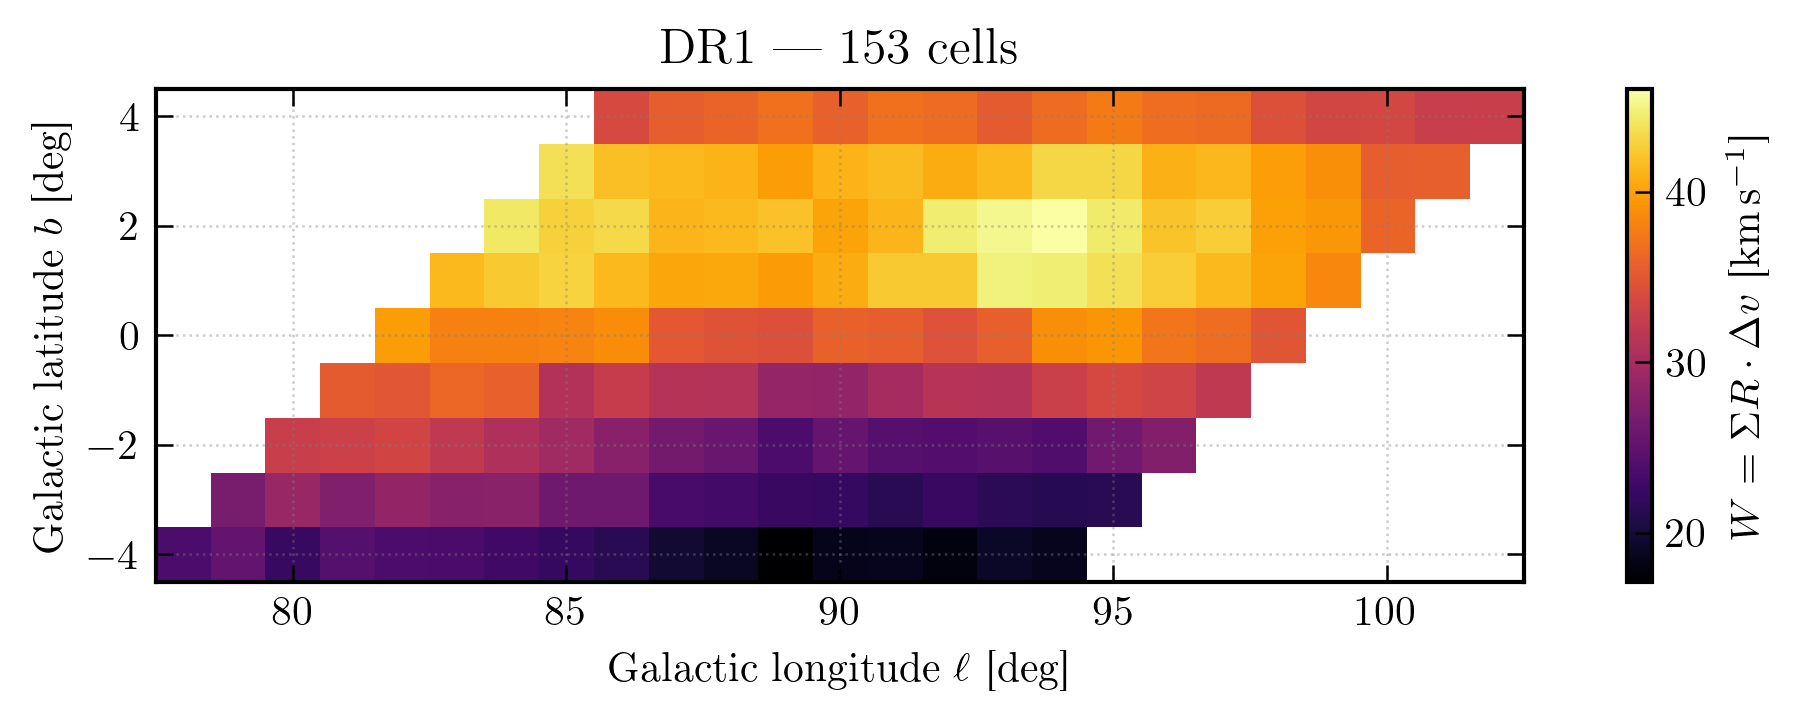

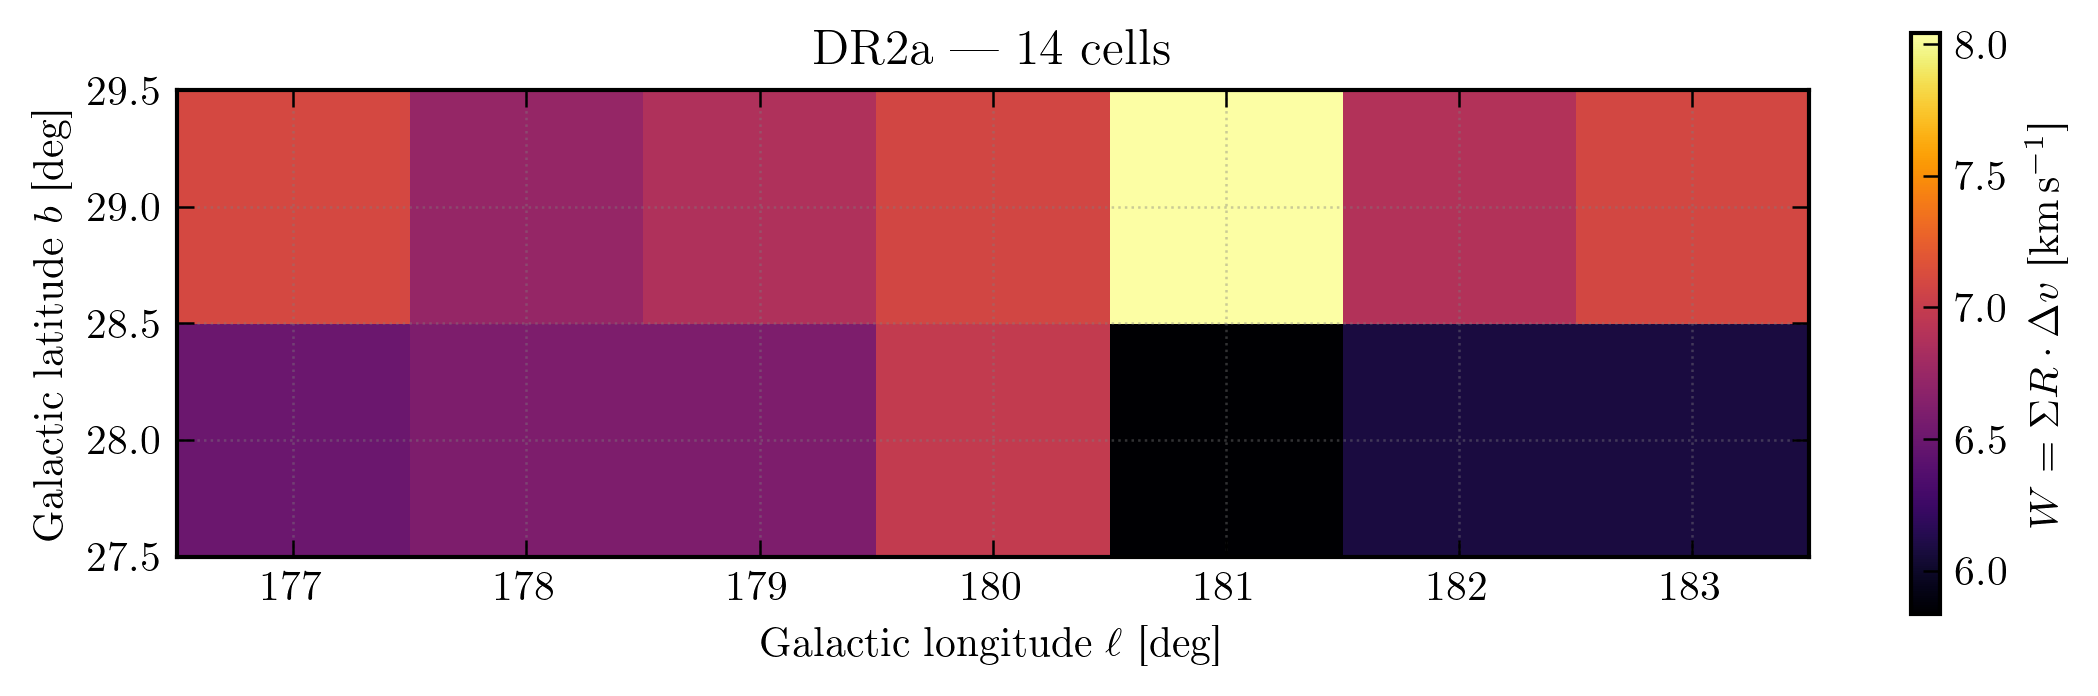

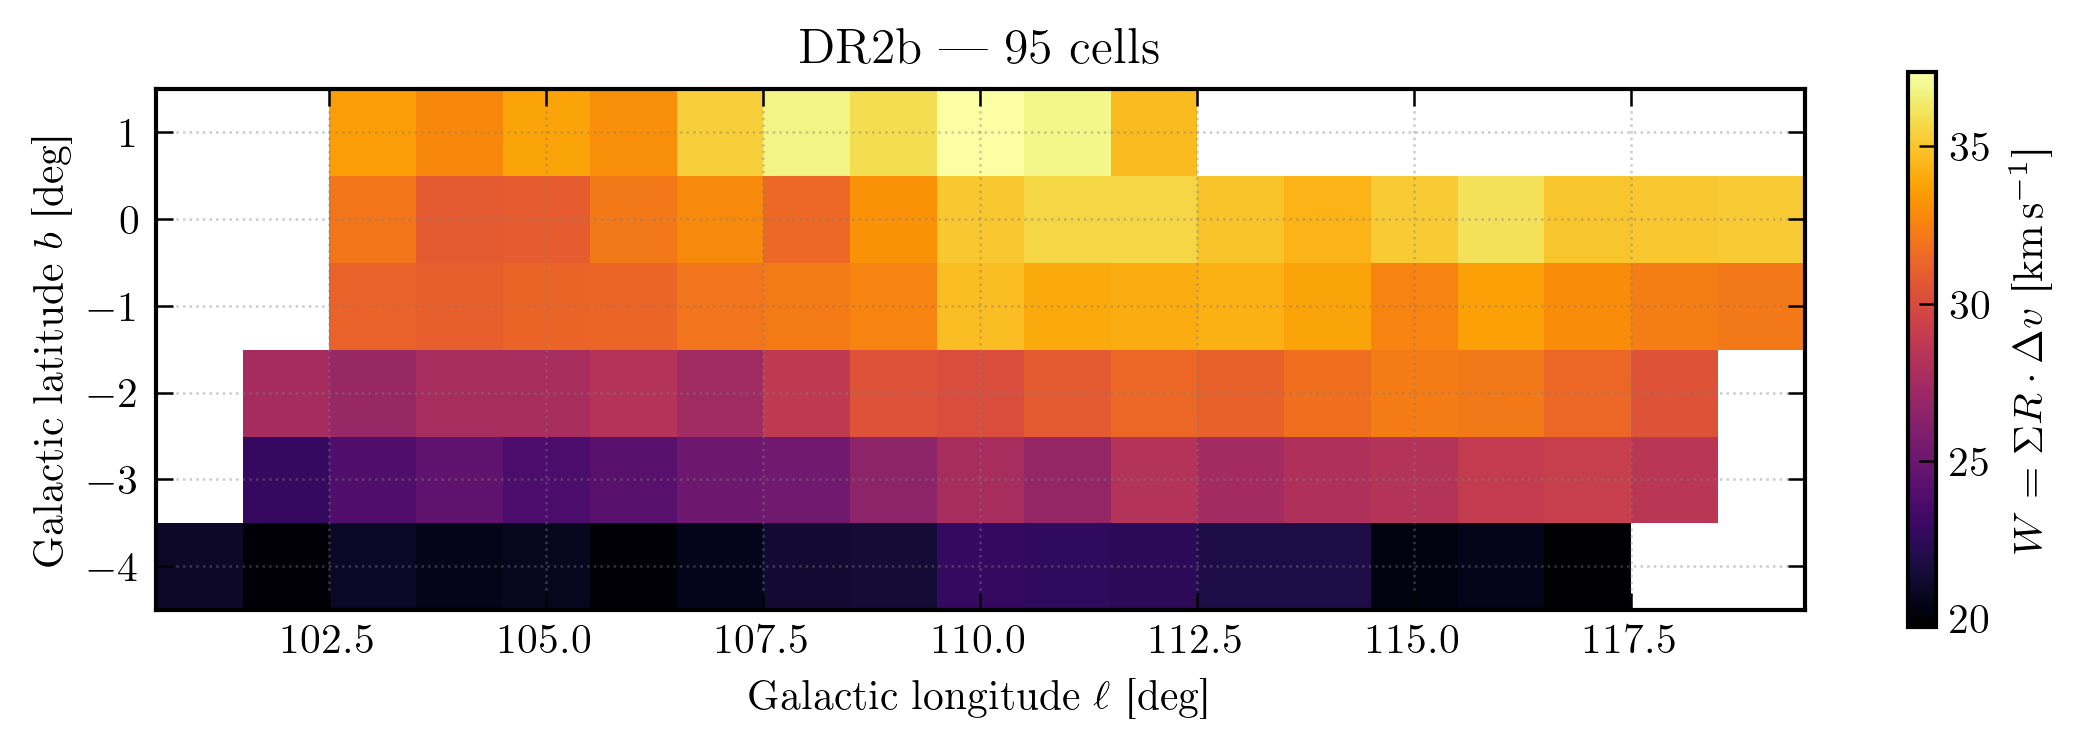

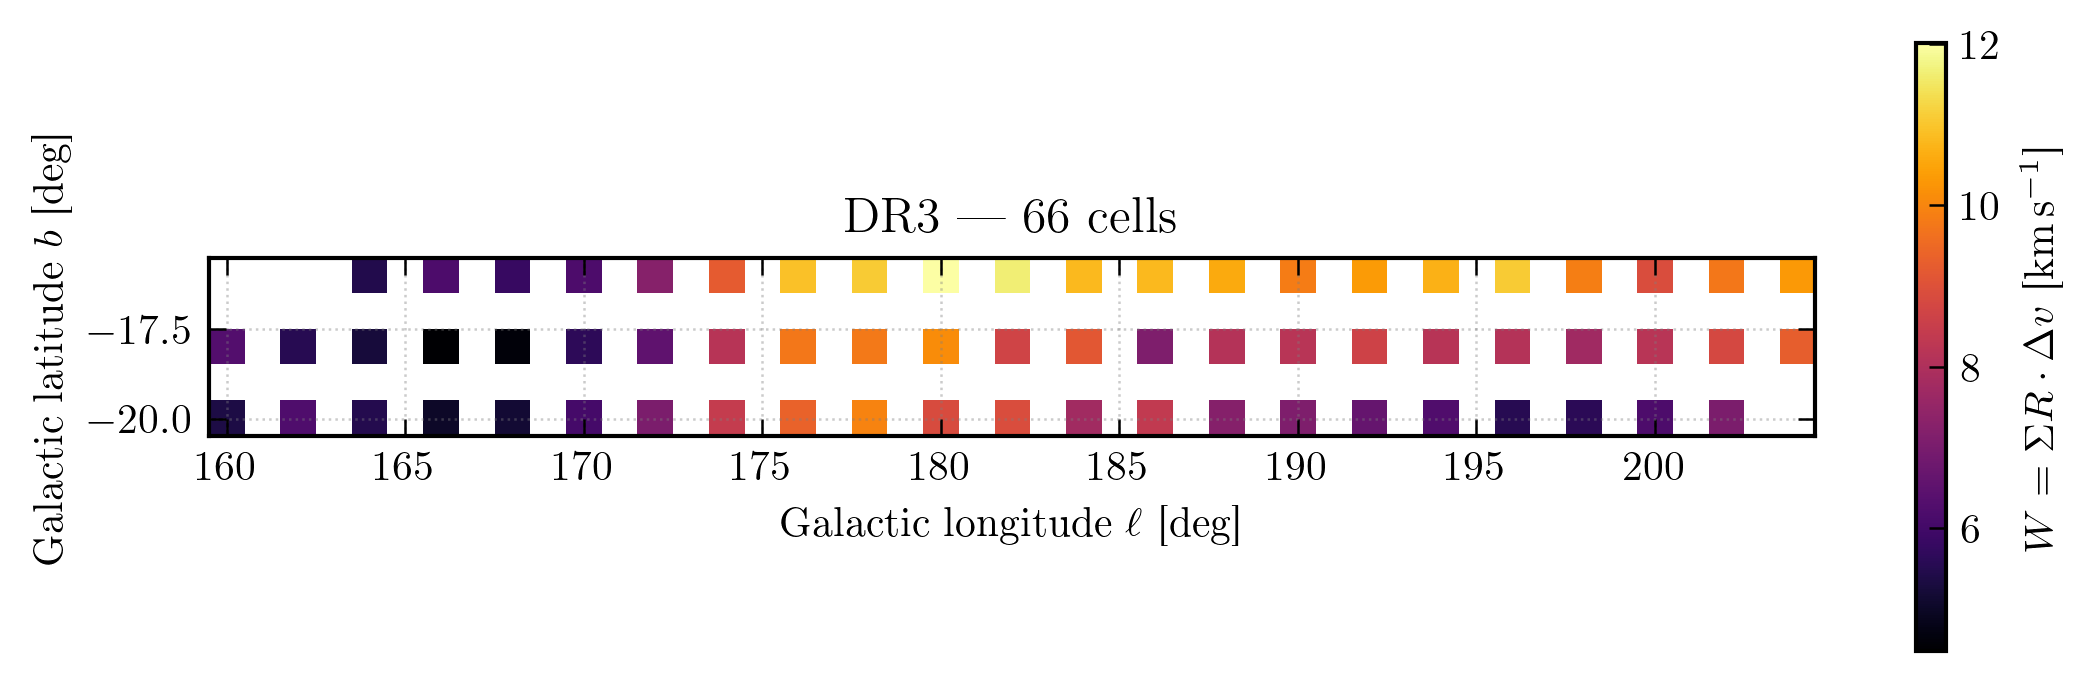

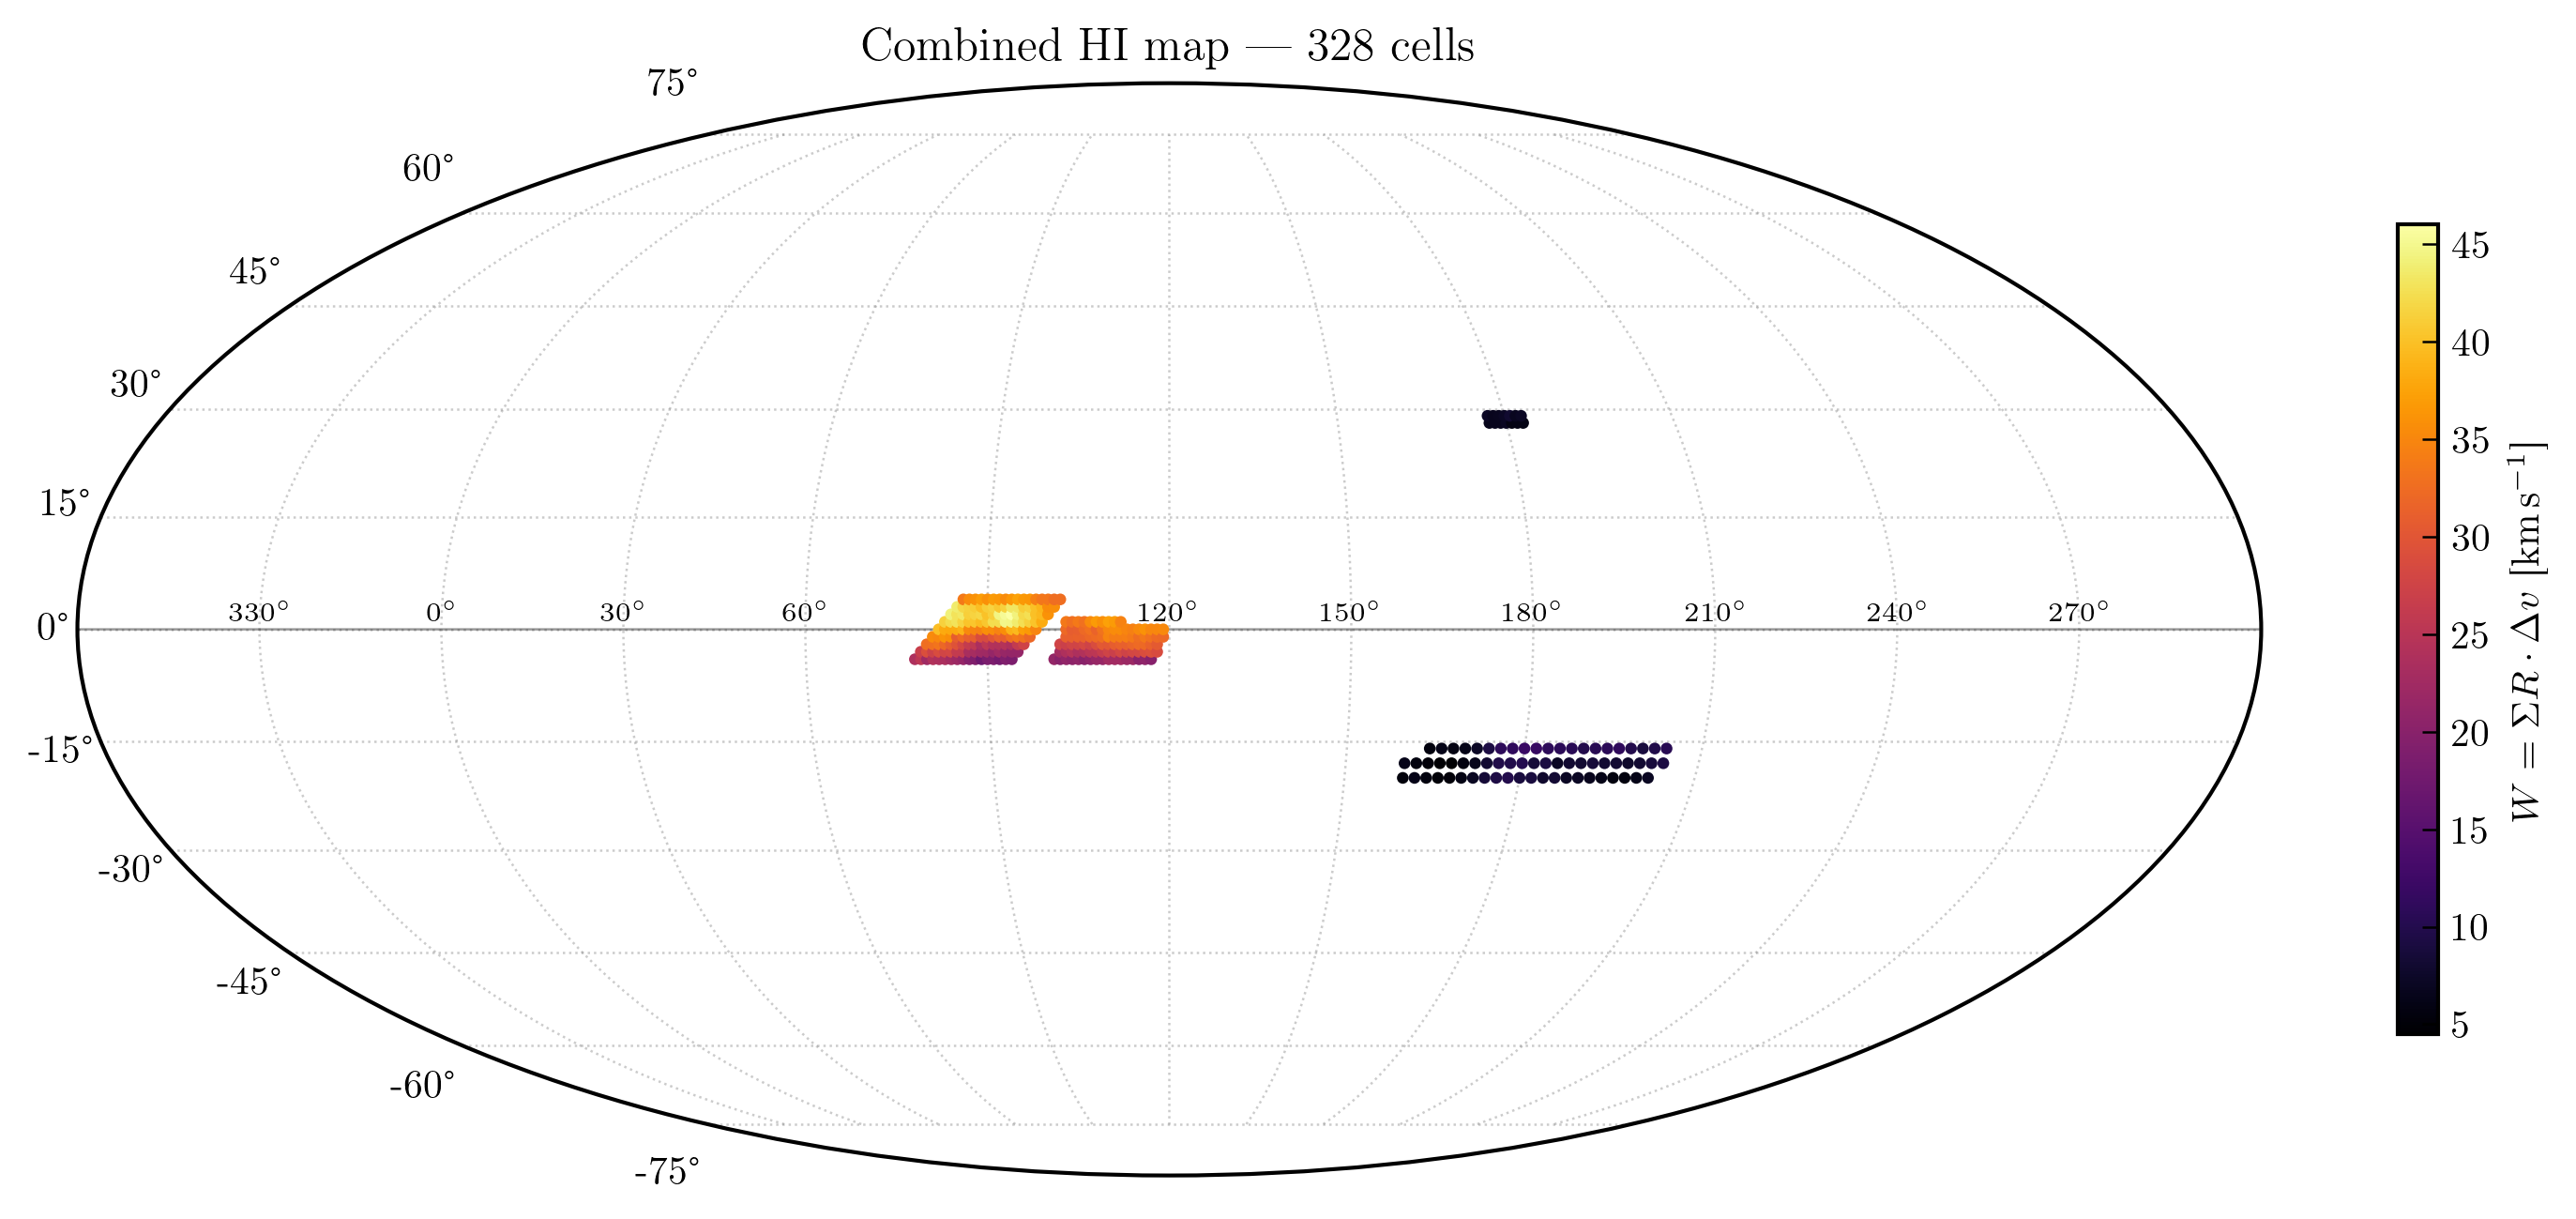

In [7]:
# Channel width in km/s
dv_kms = np.abs(np.median(np.diff(v_overlap)))

def compute_cell_W(results_dict):
    """Compute velocity-integrated R for each cell. Keys are (l, b)."""
    gl, gb, vals = [], [], []
    for key, cr in results_dict.items():
        if len(key) == 2:
            l, b = key
        else:
            _, l, b = key  # (dr, l, b)
        gl.append(l)
        gb.append(b)
        vals.append(np.nansum(cr['R_overlap']) * dv_kms)
    return np.array(gl, dtype=float), np.array(gb, dtype=float), np.array(vals)

def build_heatmap(gl, gb, vals):
    """Grid scattered (l, b, W) onto integer-degree map."""
    gl_int = np.round(gl).astype(int)
    gb_int = np.round(gb).astype(int)
    l_unique = np.arange(gl_int.min(), gl_int.max() + 1)
    b_unique = np.arange(gb_int.min(), gb_int.max() + 1)
    map_val = np.full((len(b_unique), len(l_unique)), np.nan)
    for i in range(len(vals)):
        li = np.searchsorted(l_unique, gl_int[i])
        bi = np.searchsorted(b_unique, gb_int[i])
        if 0 <= li < len(l_unique) and 0 <= bi < len(b_unique):
            map_val[bi, li] = vals[i]
    return map_val, l_unique, b_unique

print(f'dv = {dv_kms:.3f} km/s per channel')
print(f'Overlap channels: {overlap_mask.sum()}')
print(f'Total velocity range: {overlap_mask.sum() * dv_kms:.1f} km/s')

# --- Per-DR flat maps ---
for dr in DATA_RELEASES:
    dr_results = {(l, b): v for (d, l, b), v in cell_results.items() if d == dr}
    if not dr_results:
        continue
    gl, gb, vals = compute_cell_W(dr_results)
    fig, ax = plot_heatmap(gl, gb, vals, title=f'{dr} — {len(vals)} cells')
    plt.show()

# --- Combined Mollweide projection ---
MOLL_CENTER_L = 120.0

gl_all, gb_all, W_all = compute_cell_W(cell_results_combined)
fig, ax = plot_survey_mollweide(
    gl_all, gb_all, W_all,
    center_l=MOLL_CENTER_L,
    title=f'Combined HI map — {len(W_all)} cells',
)
plt.show()

## 5. All spectra per DR

/home/ikaros/projects/ay-121/labs/04/notebooks/../plotters.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/ikaros/projects/ay-121/labs/04/notebooks/../plotters.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/ikaros/projects/ay-121/labs/04/notebooks/../plotters.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


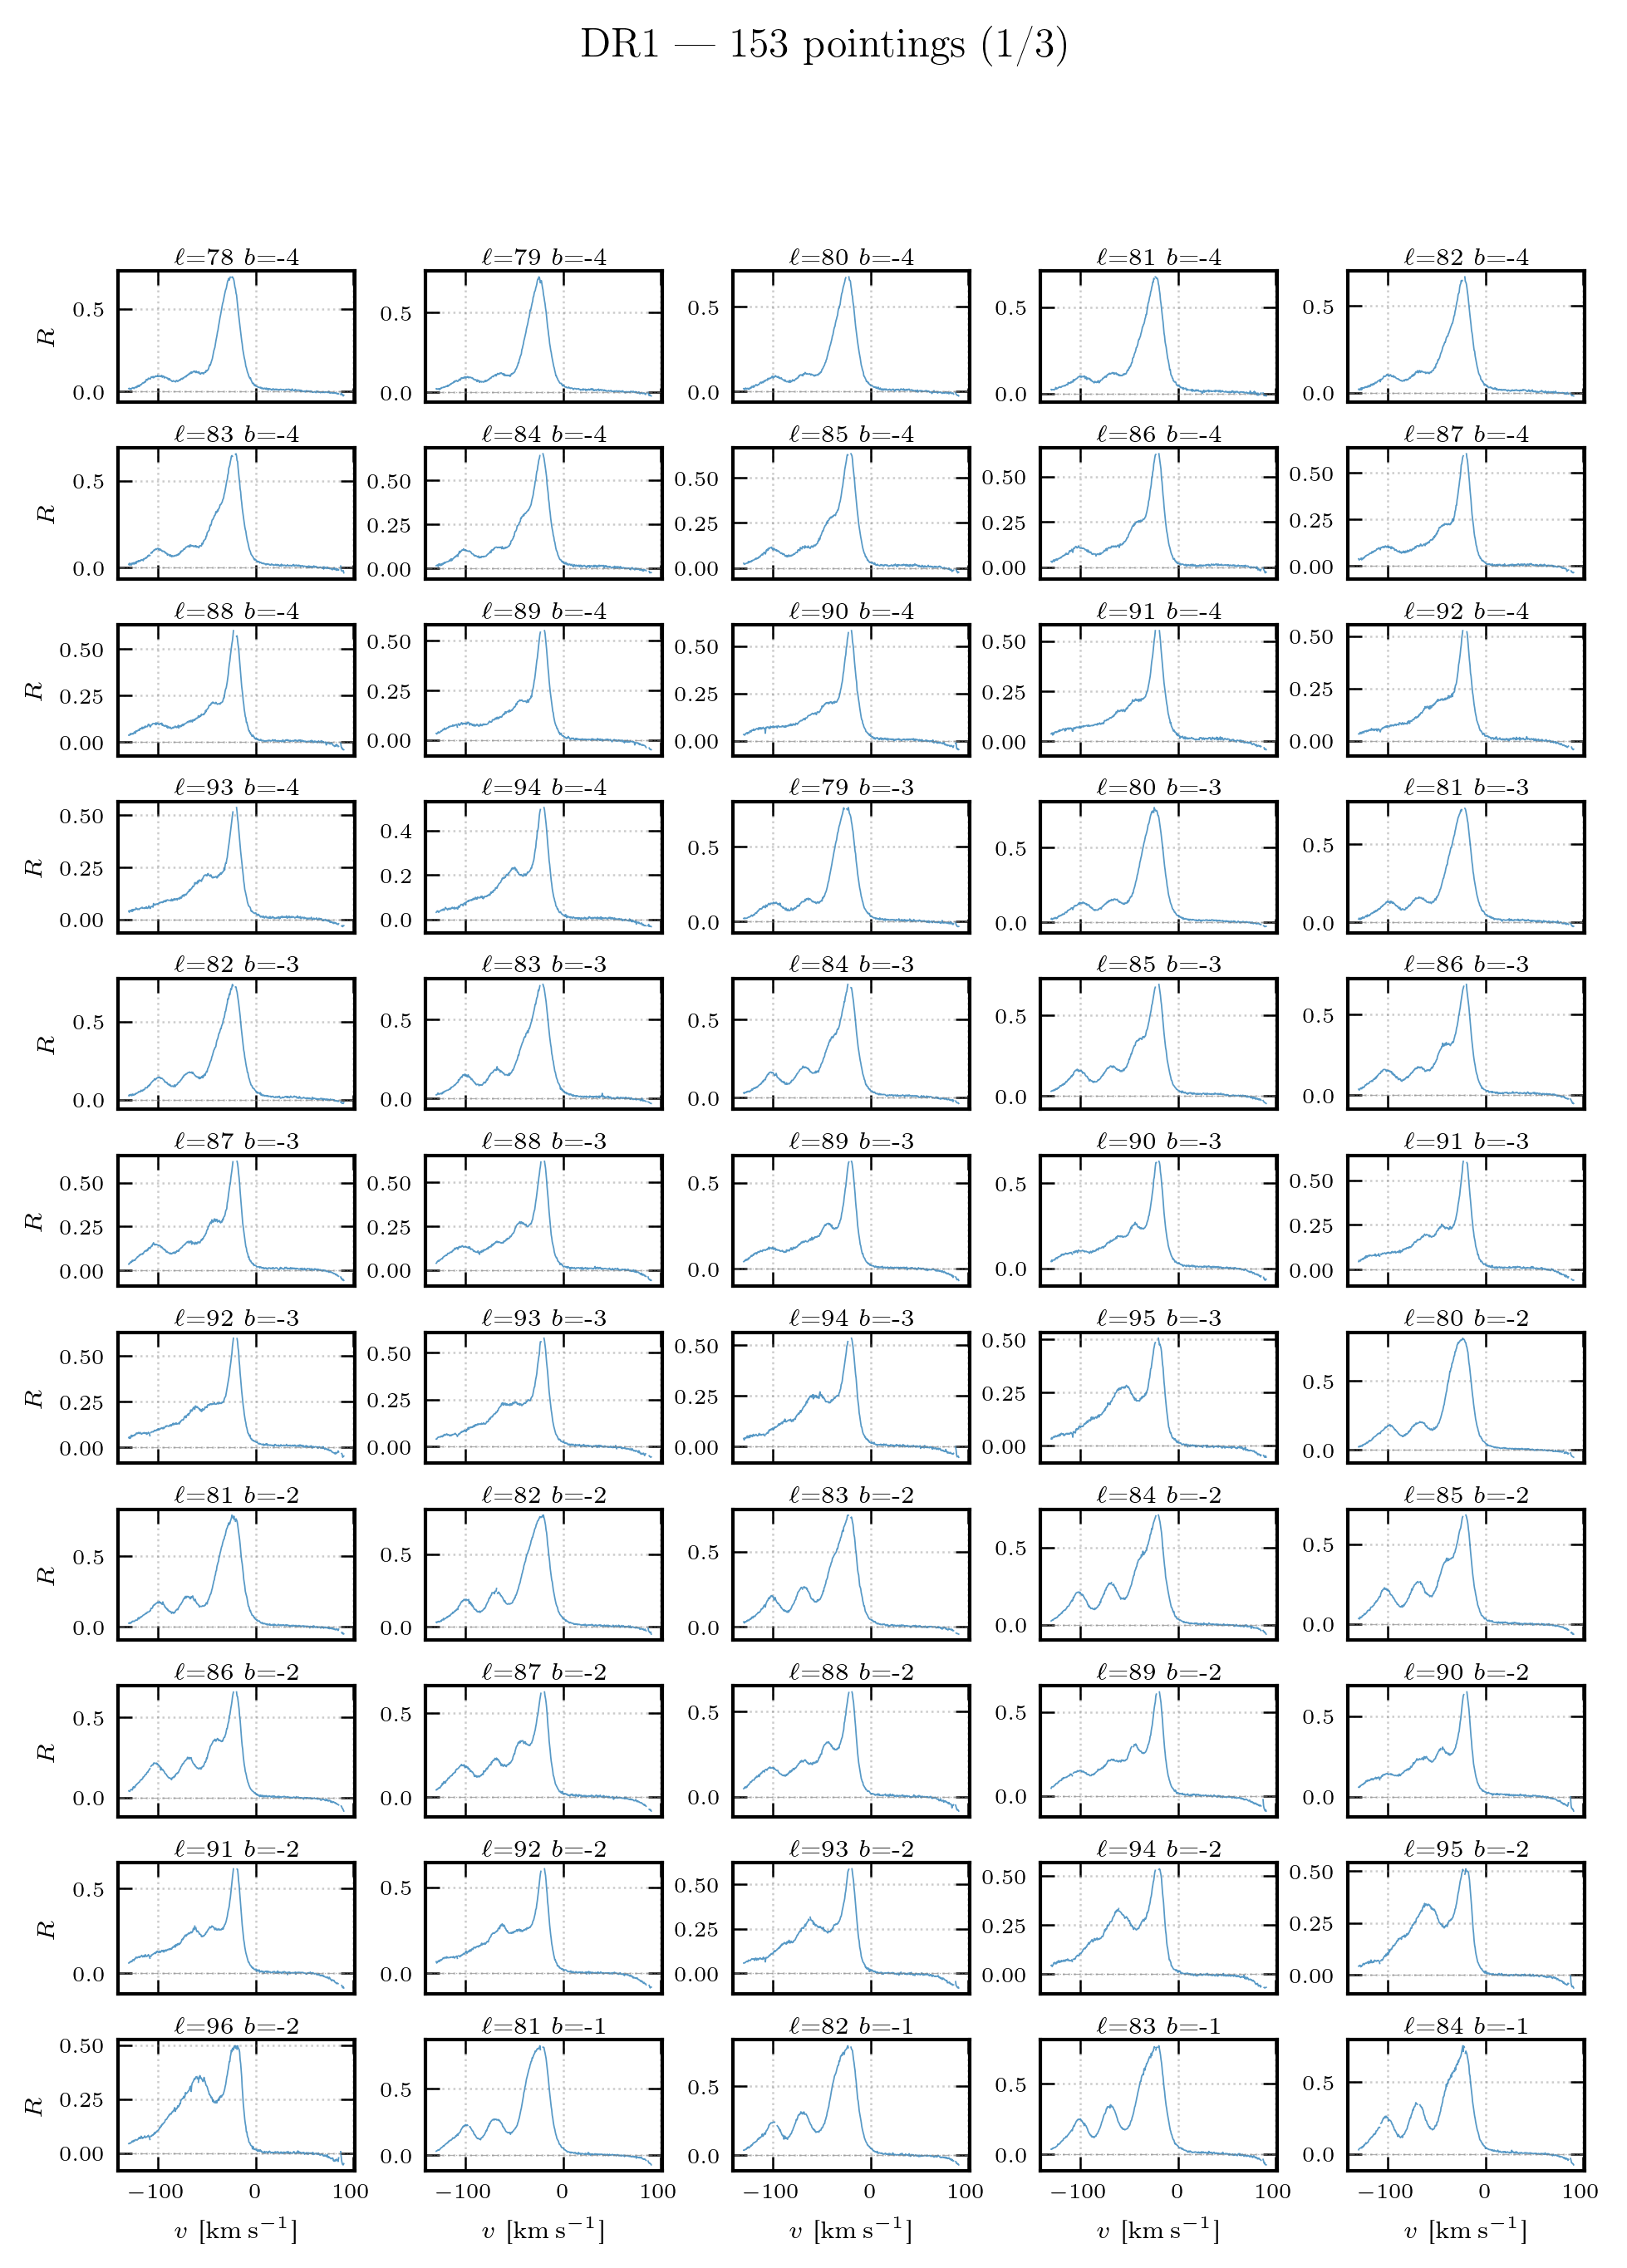

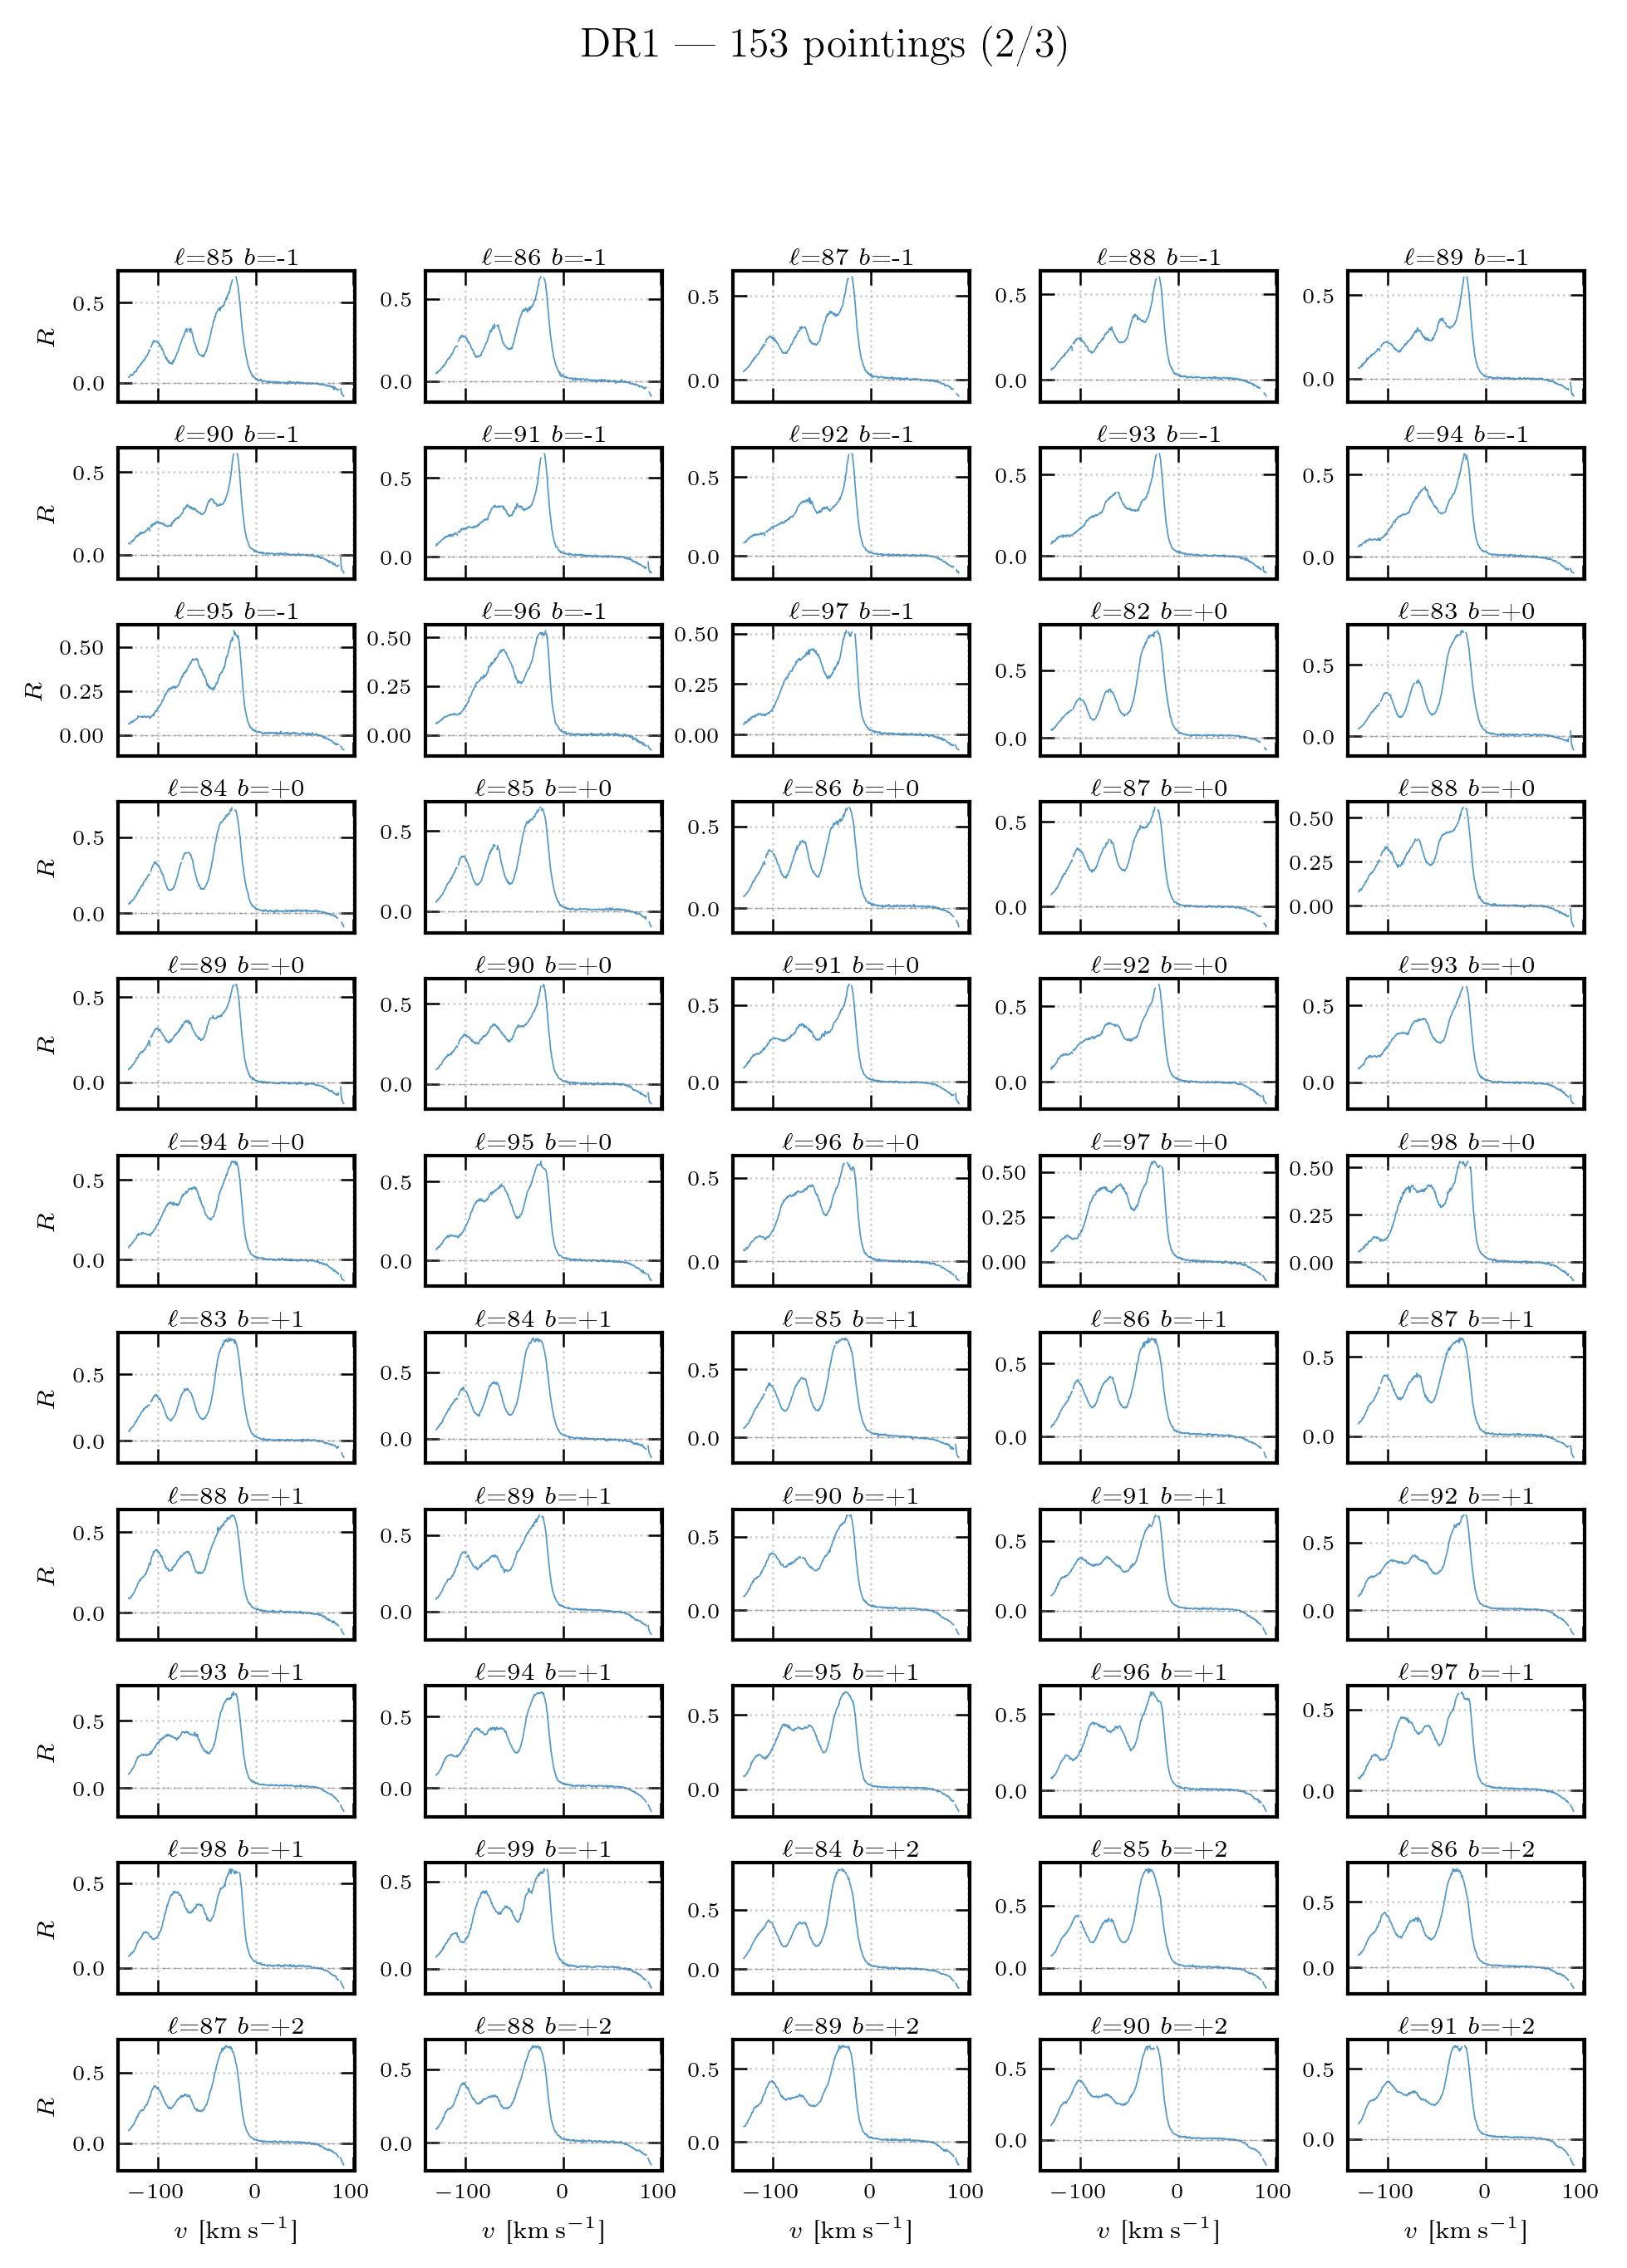

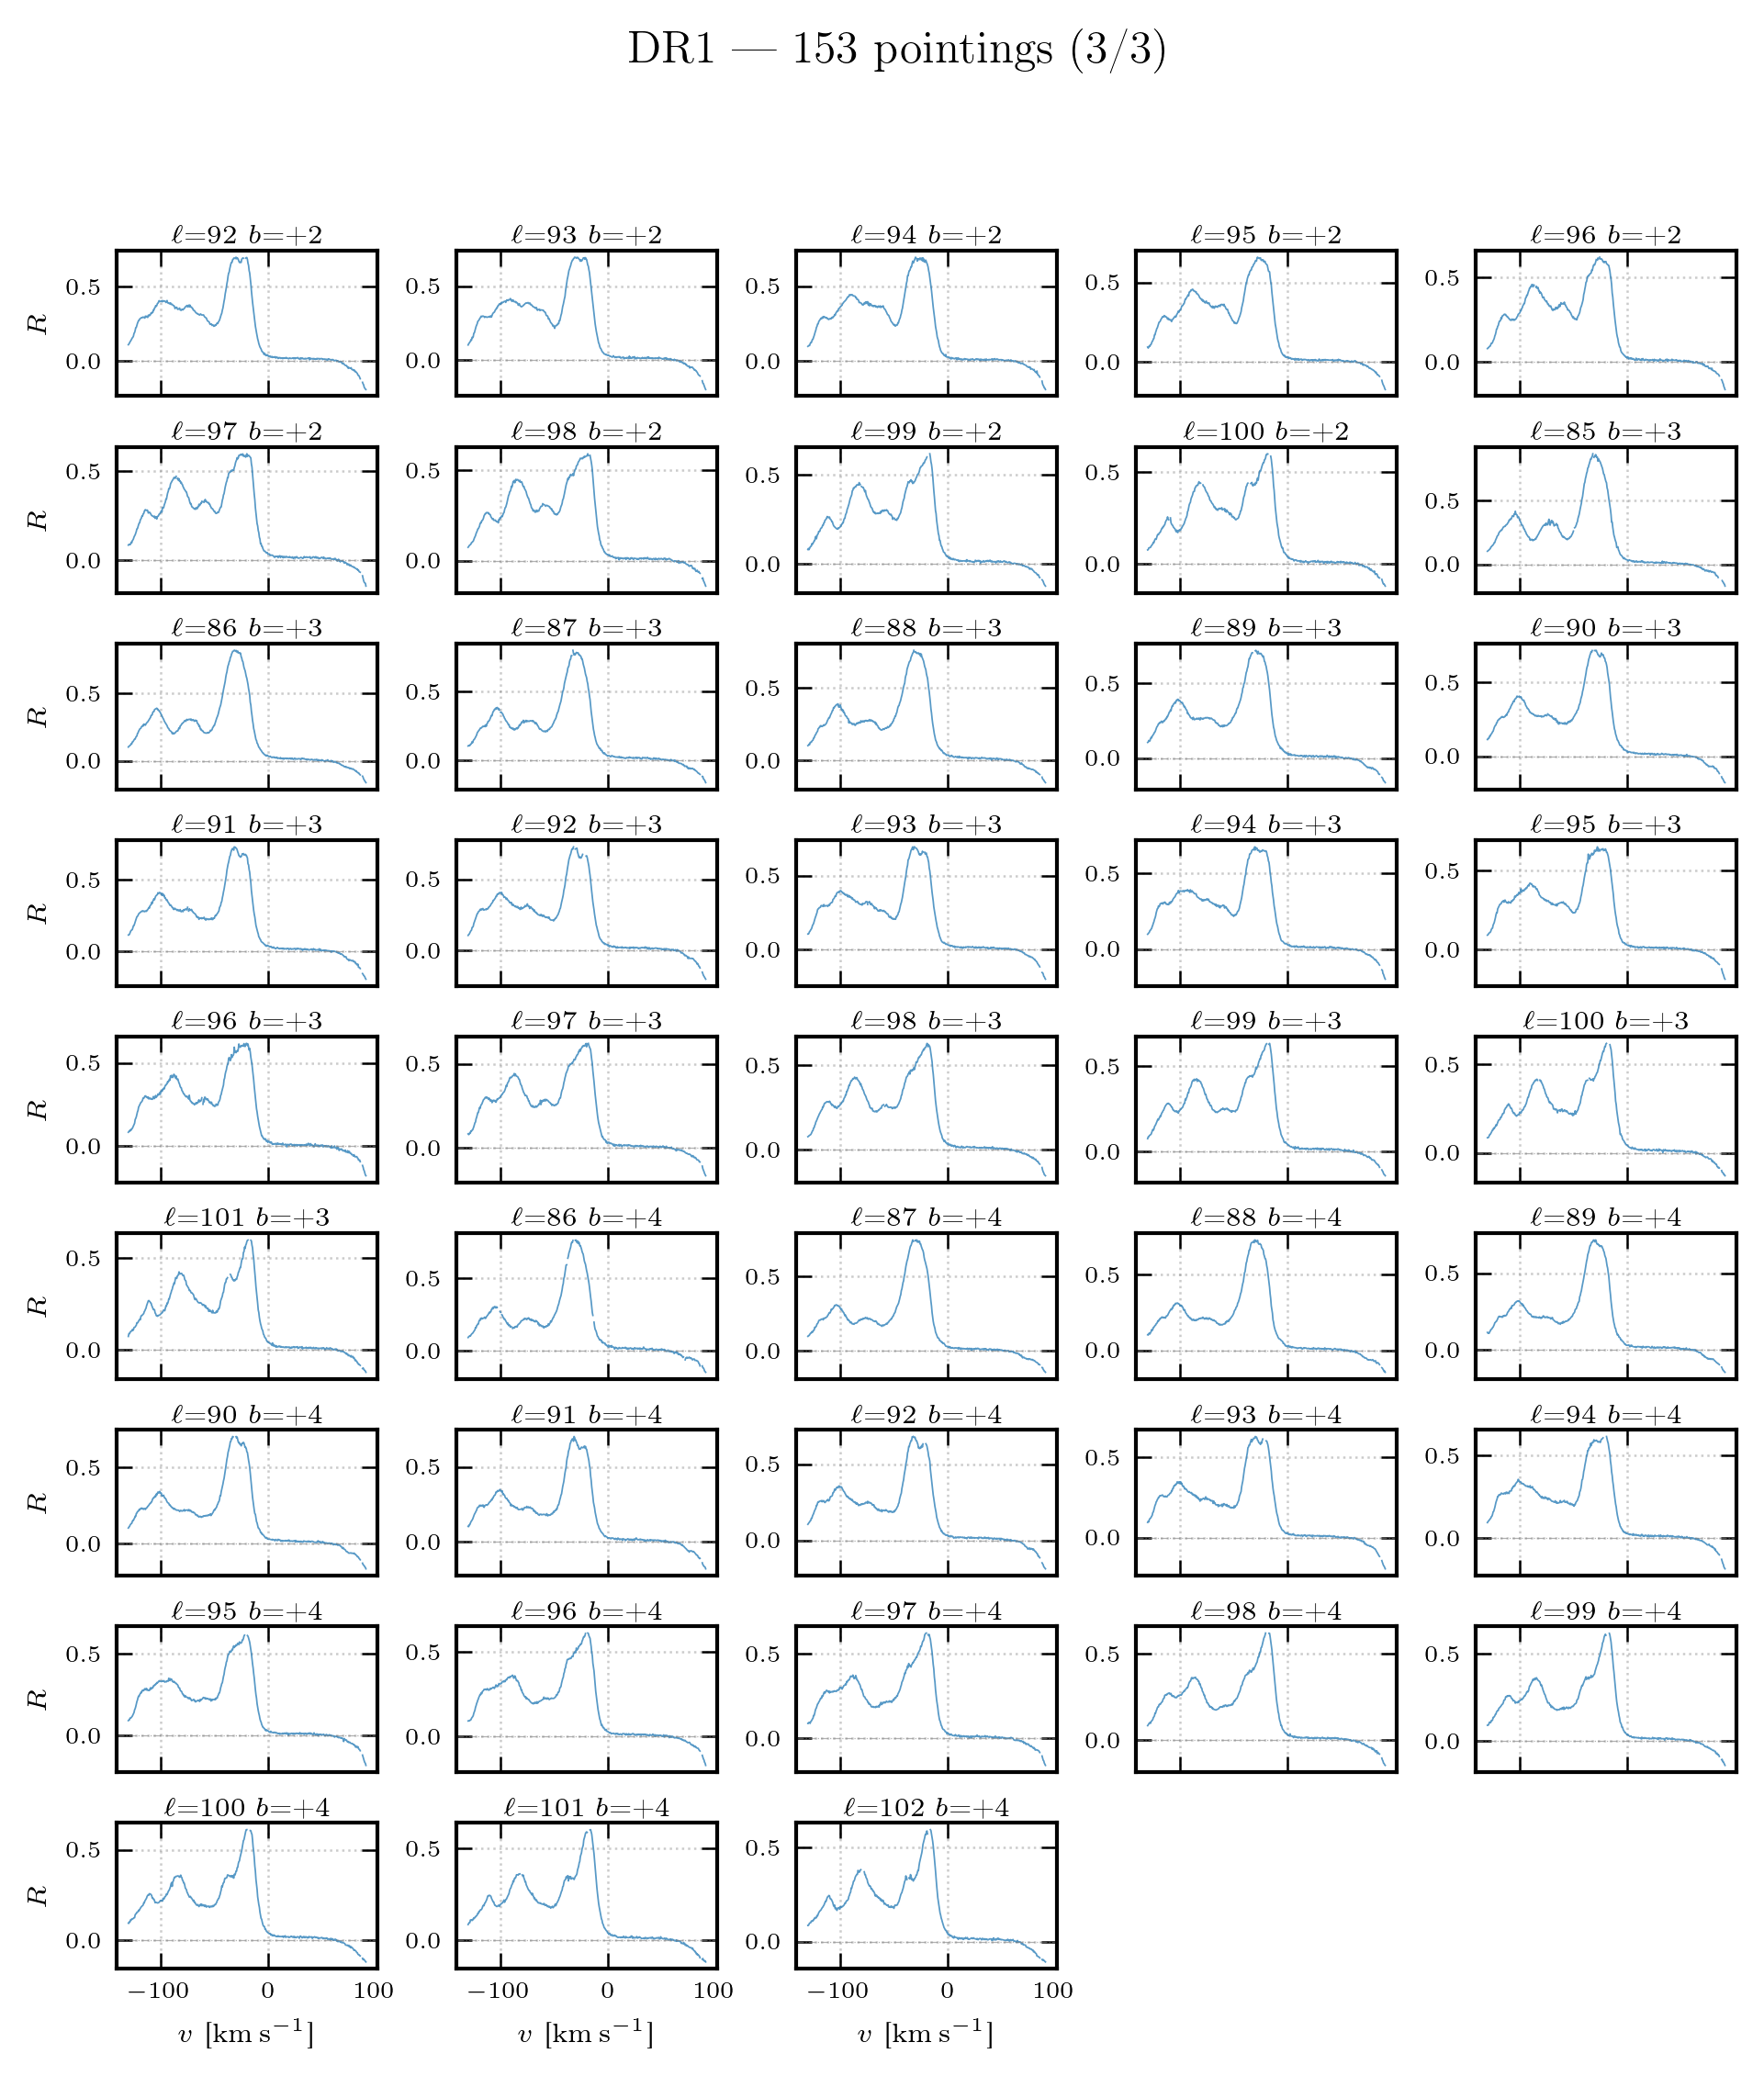

/home/ikaros/projects/ay-121/labs/04/notebooks/../plotters.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


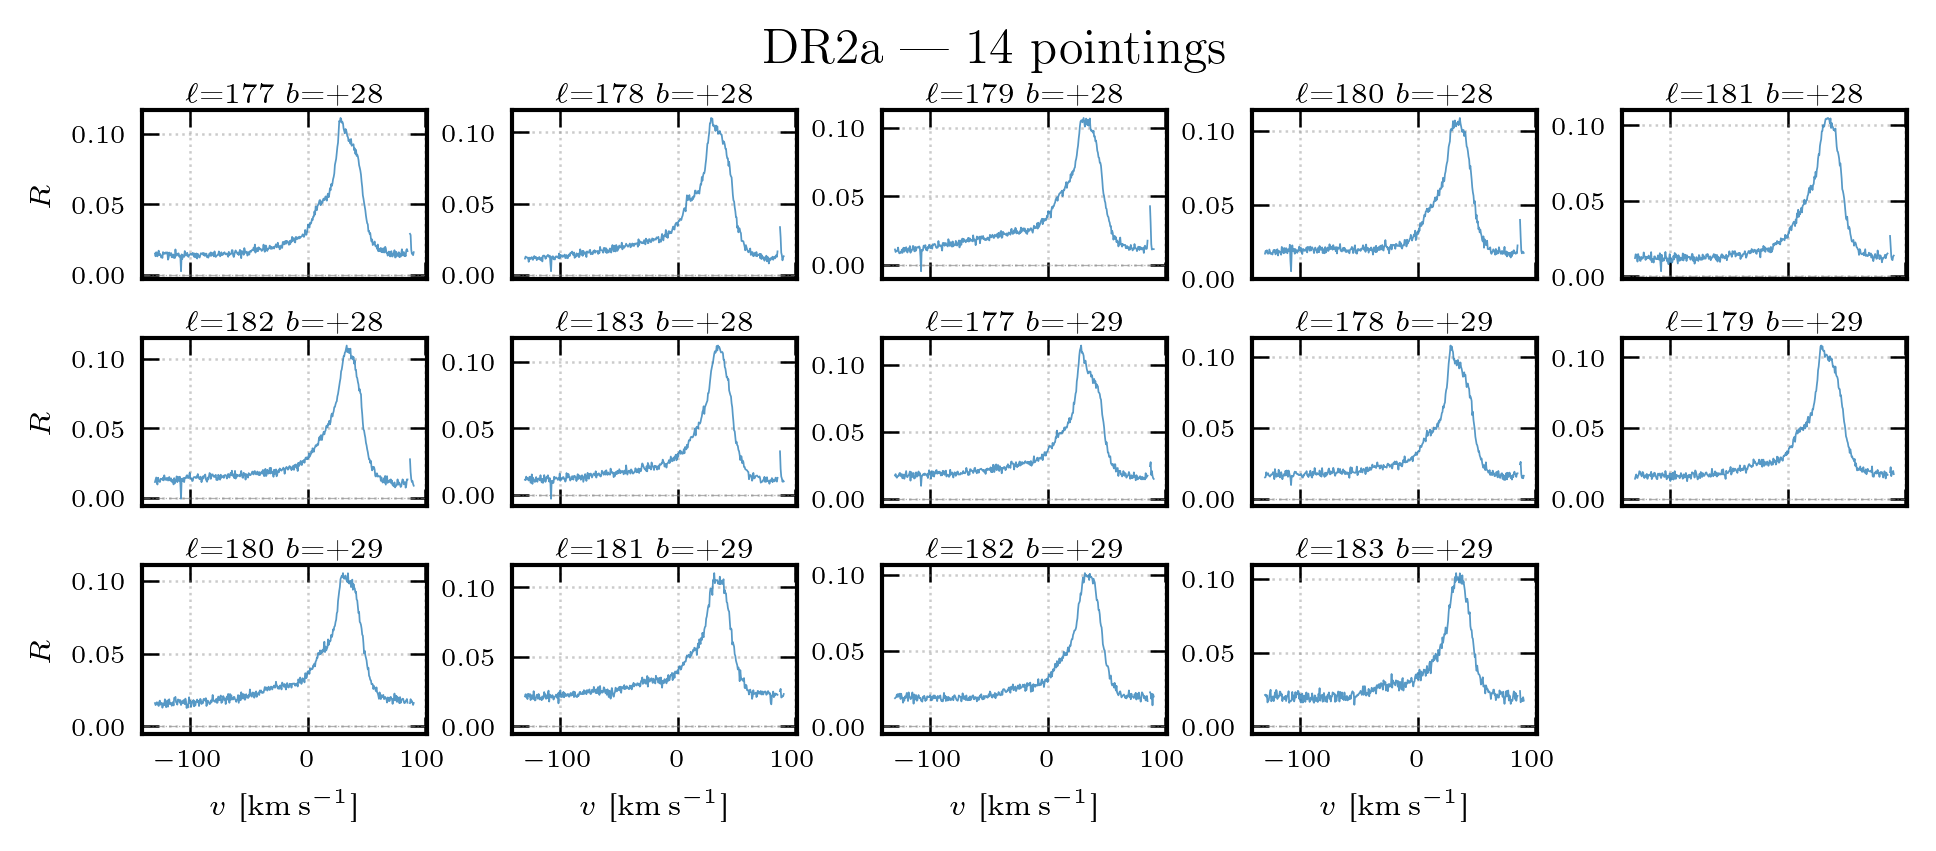

/home/ikaros/projects/ay-121/labs/04/notebooks/../plotters.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/ikaros/projects/ay-121/labs/04/notebooks/../plotters.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


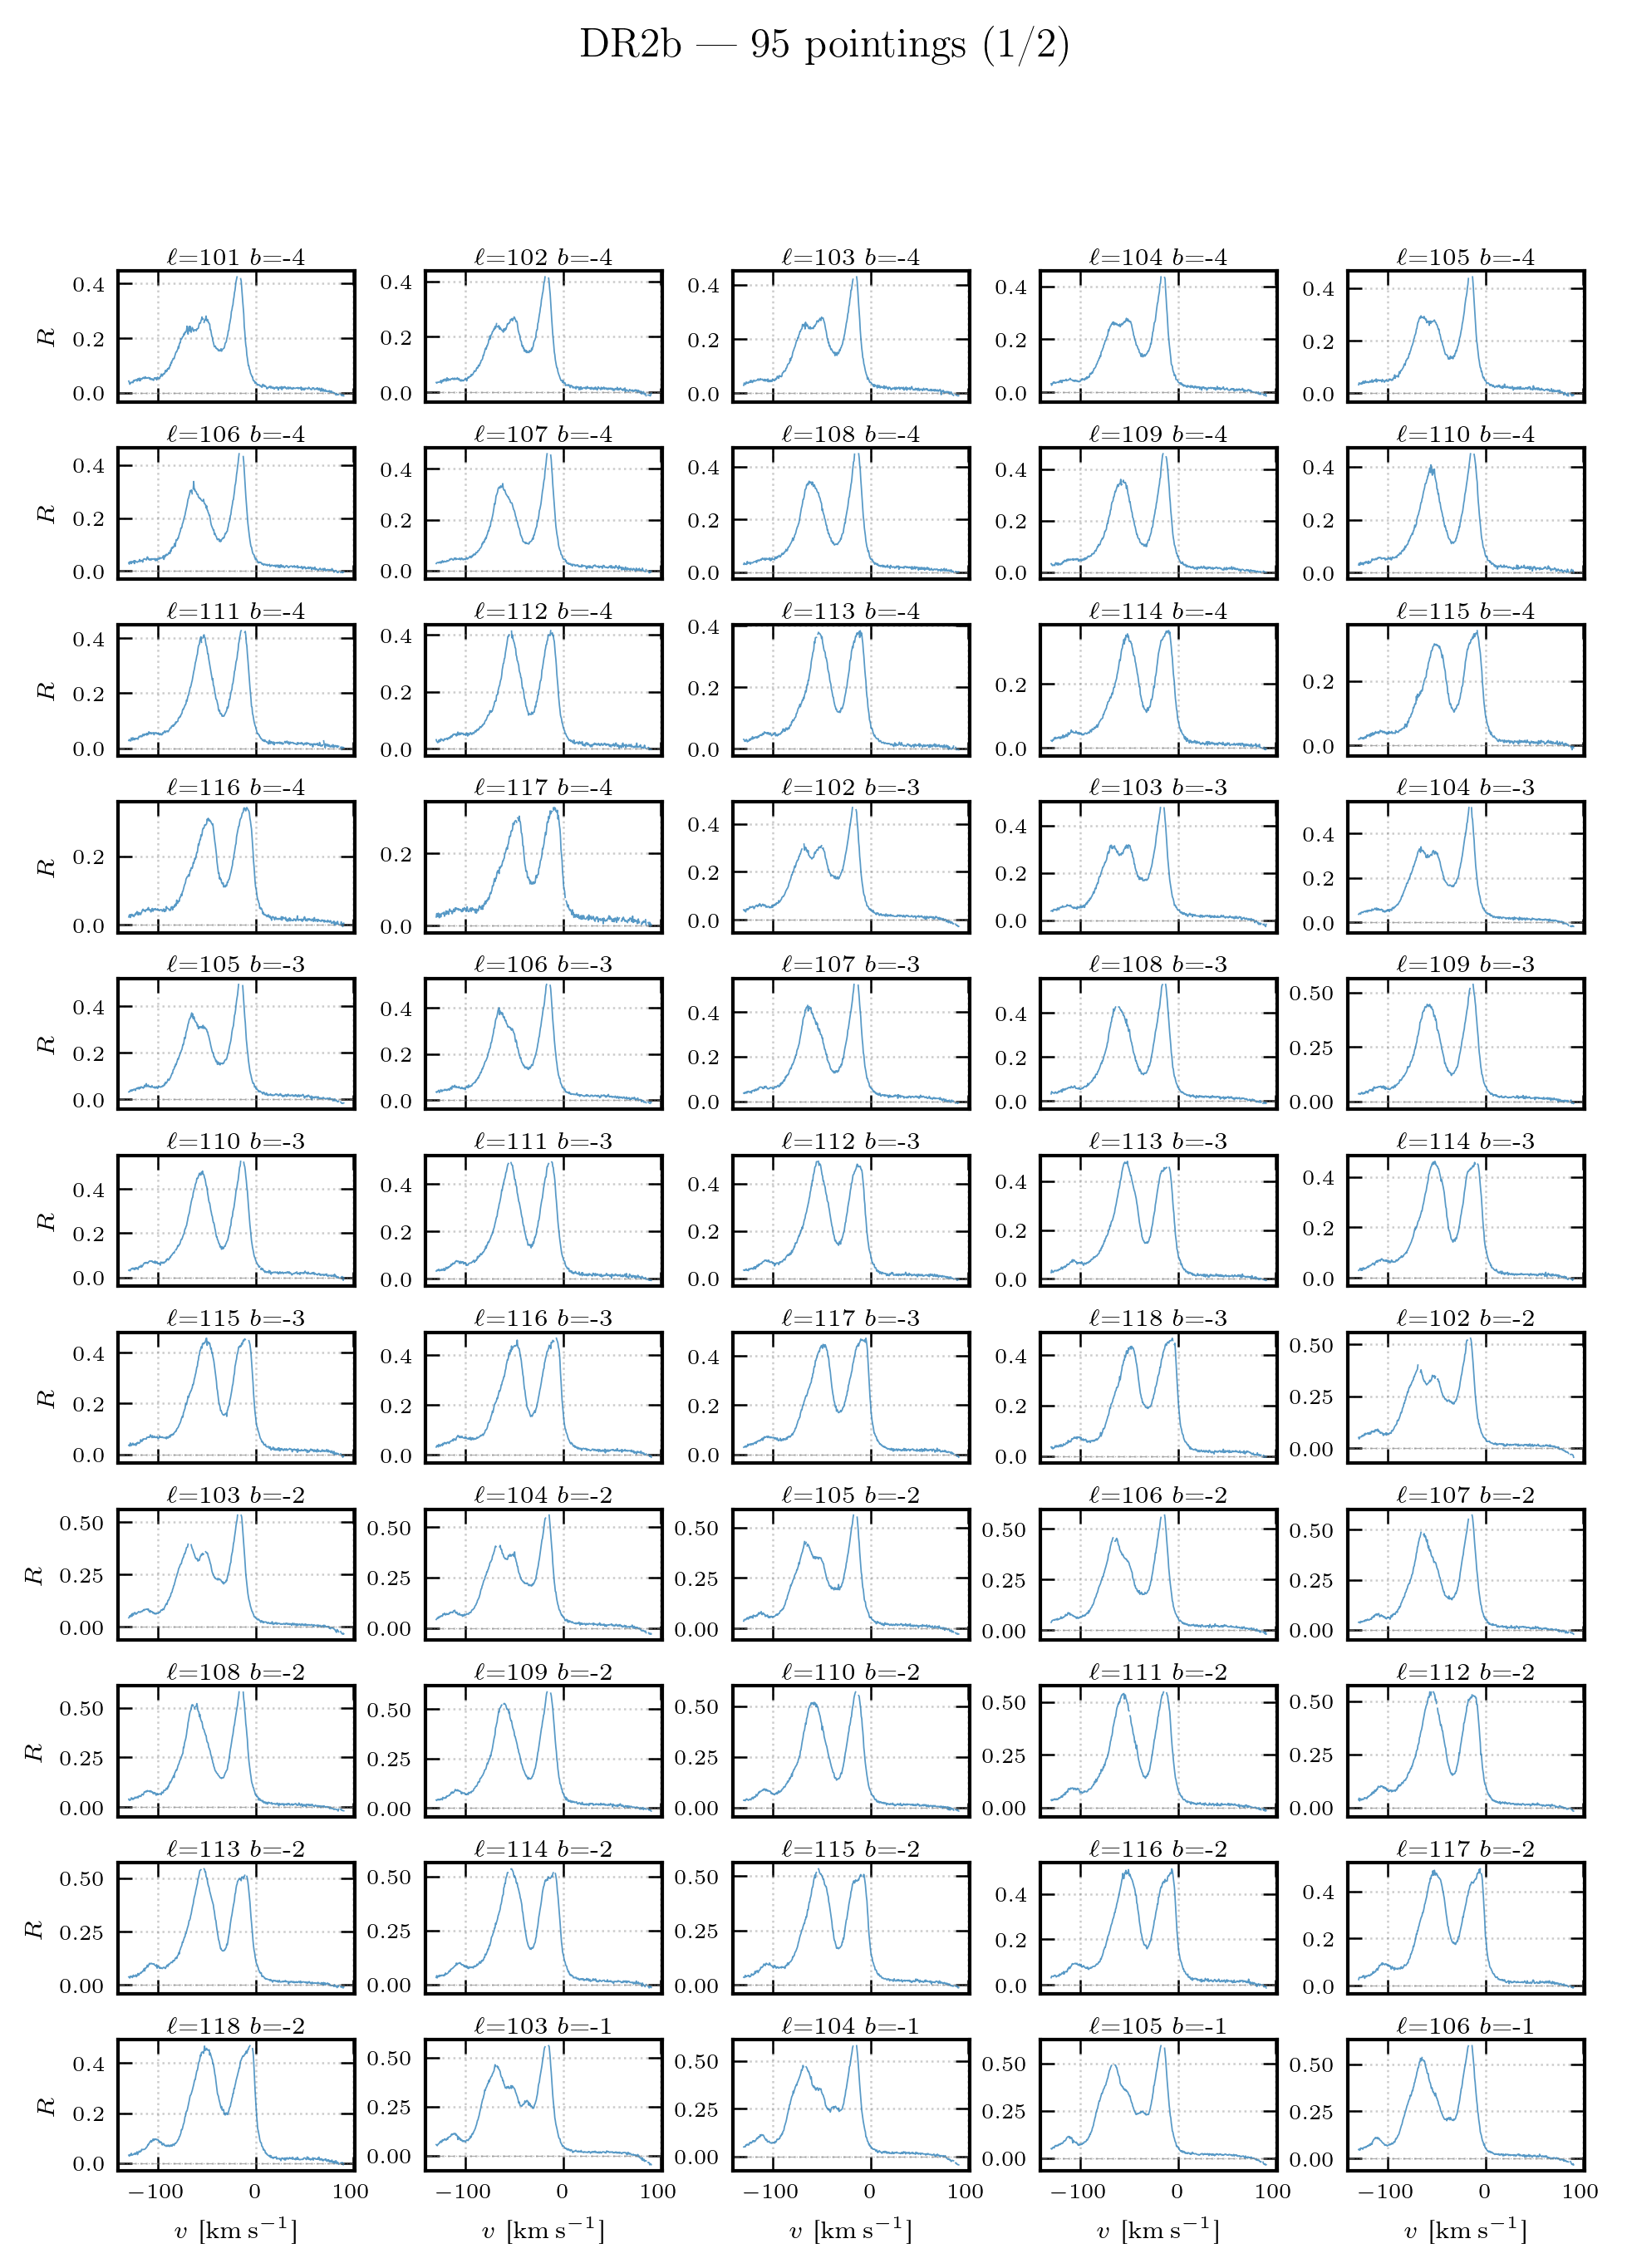

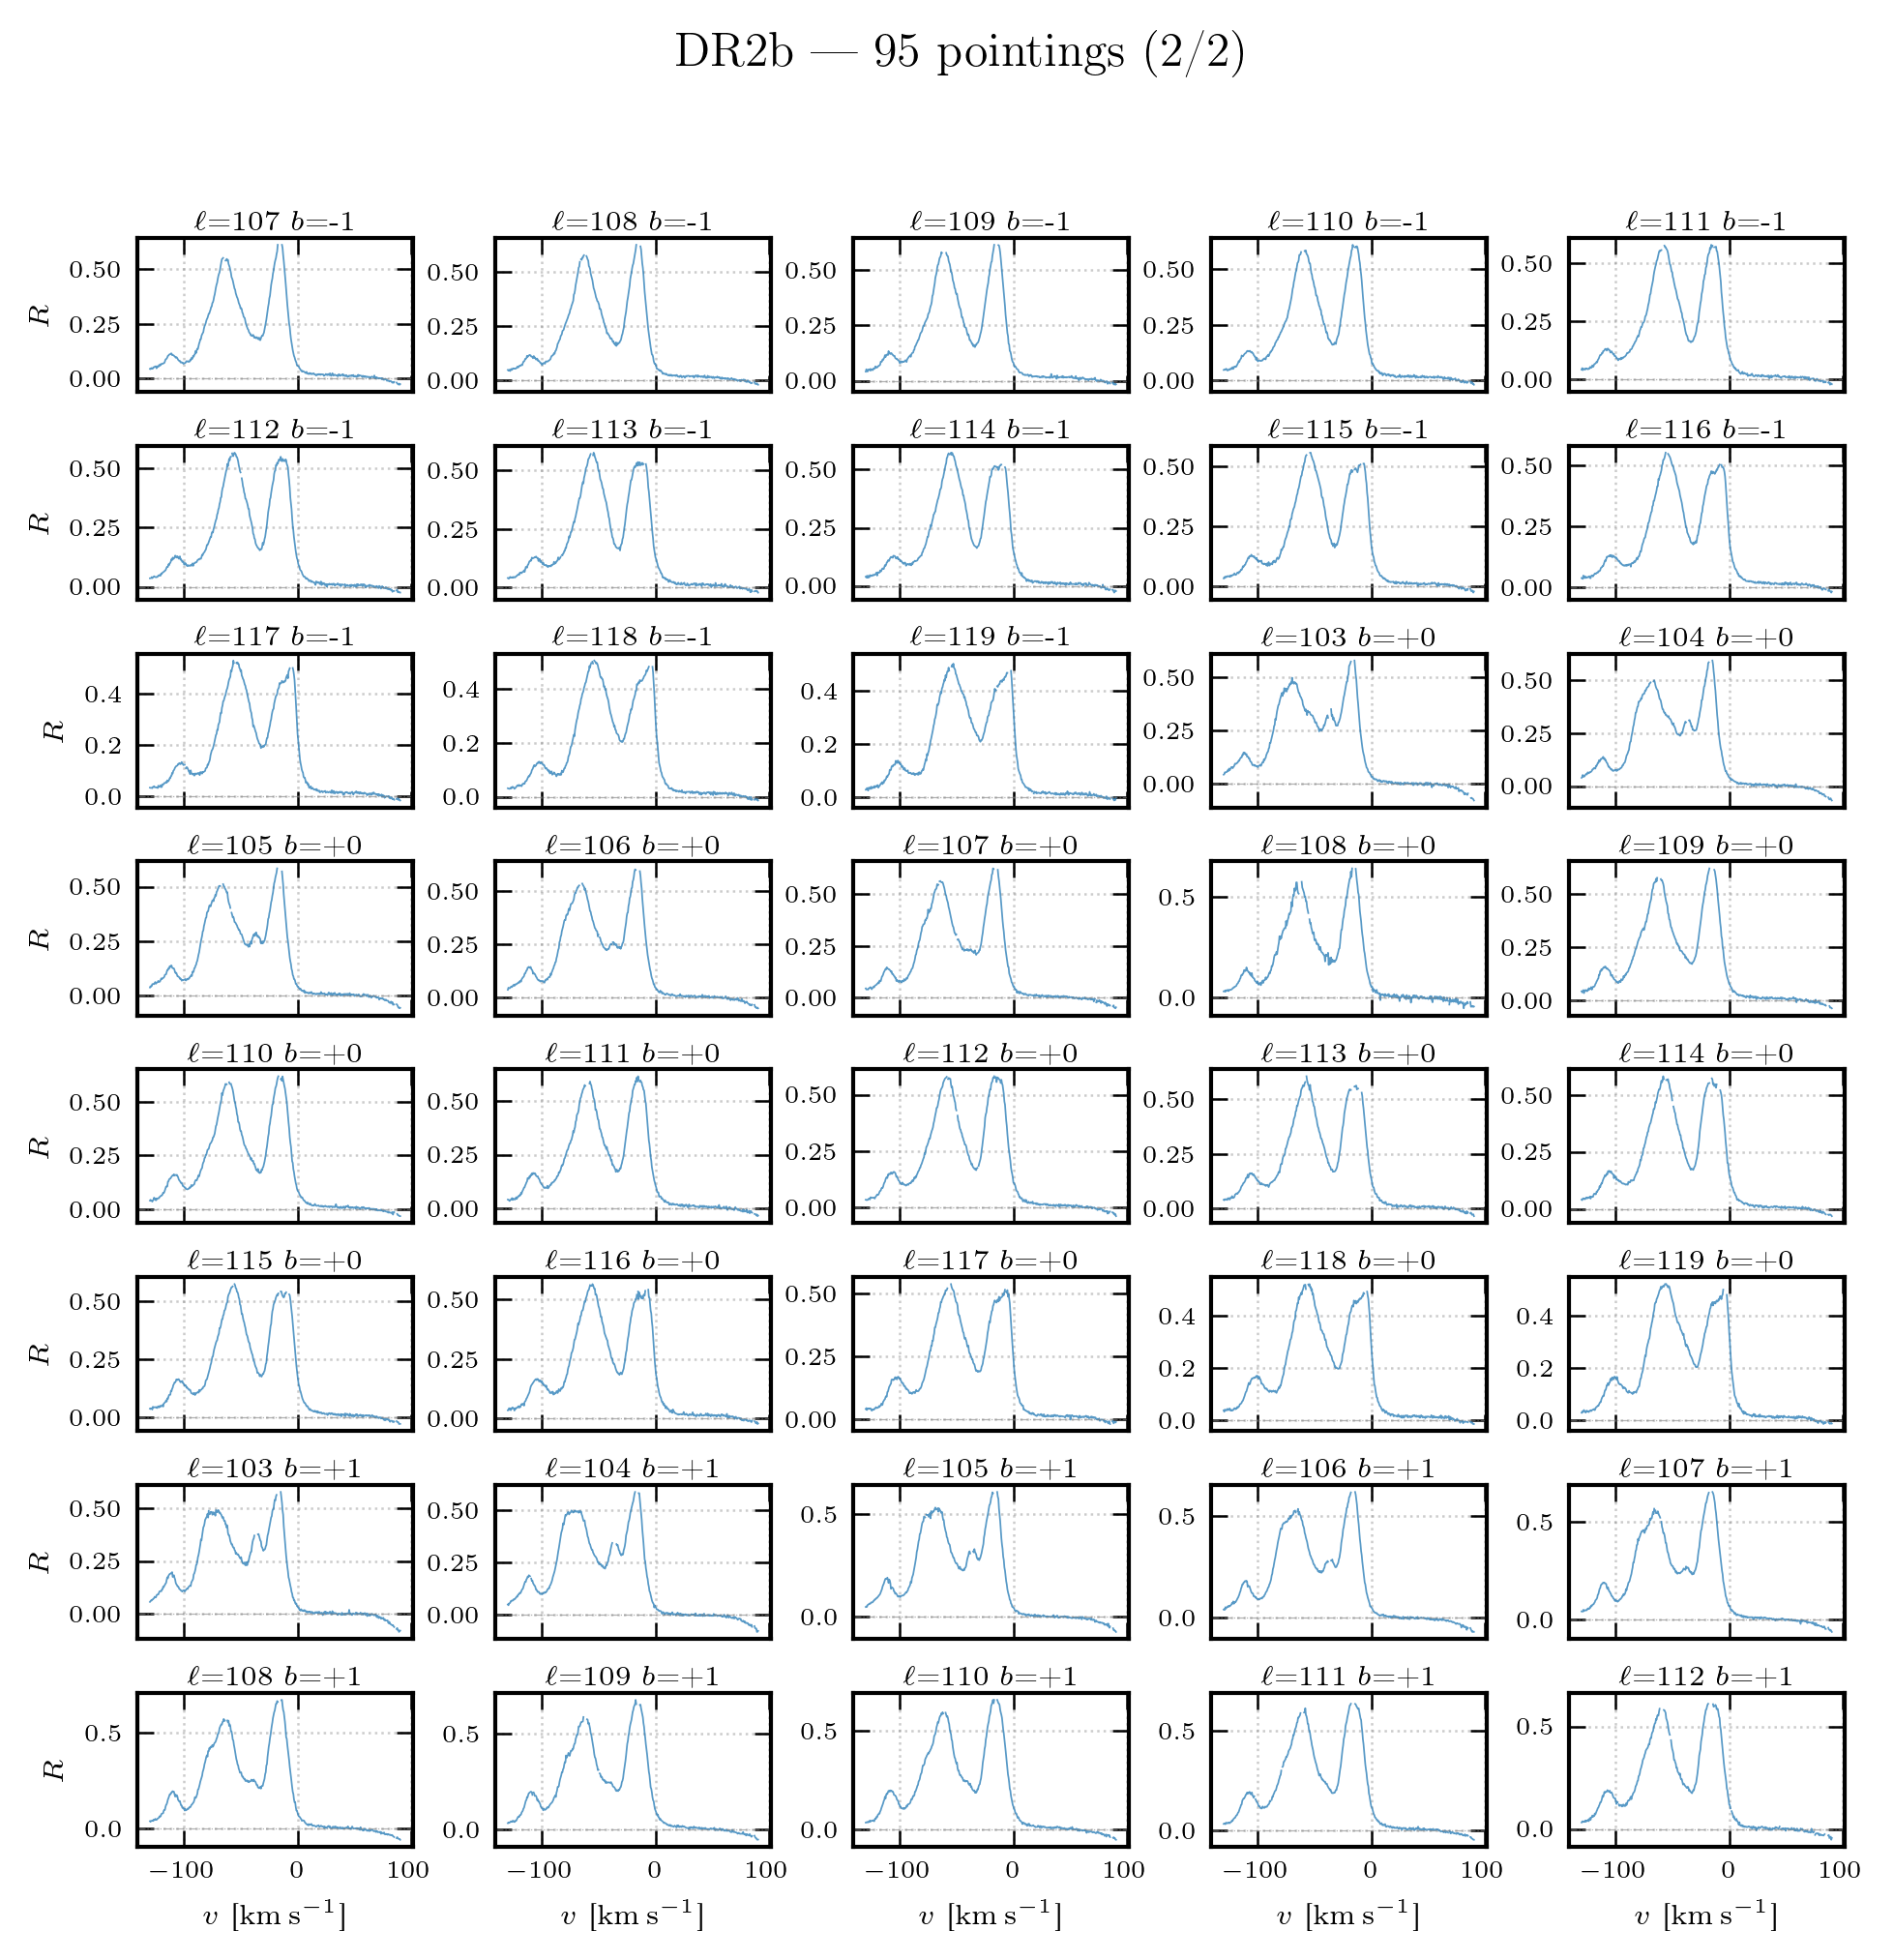

/home/ikaros/projects/ay-121/labs/04/notebooks/../plotters.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/ikaros/projects/ay-121/labs/04/notebooks/../plotters.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


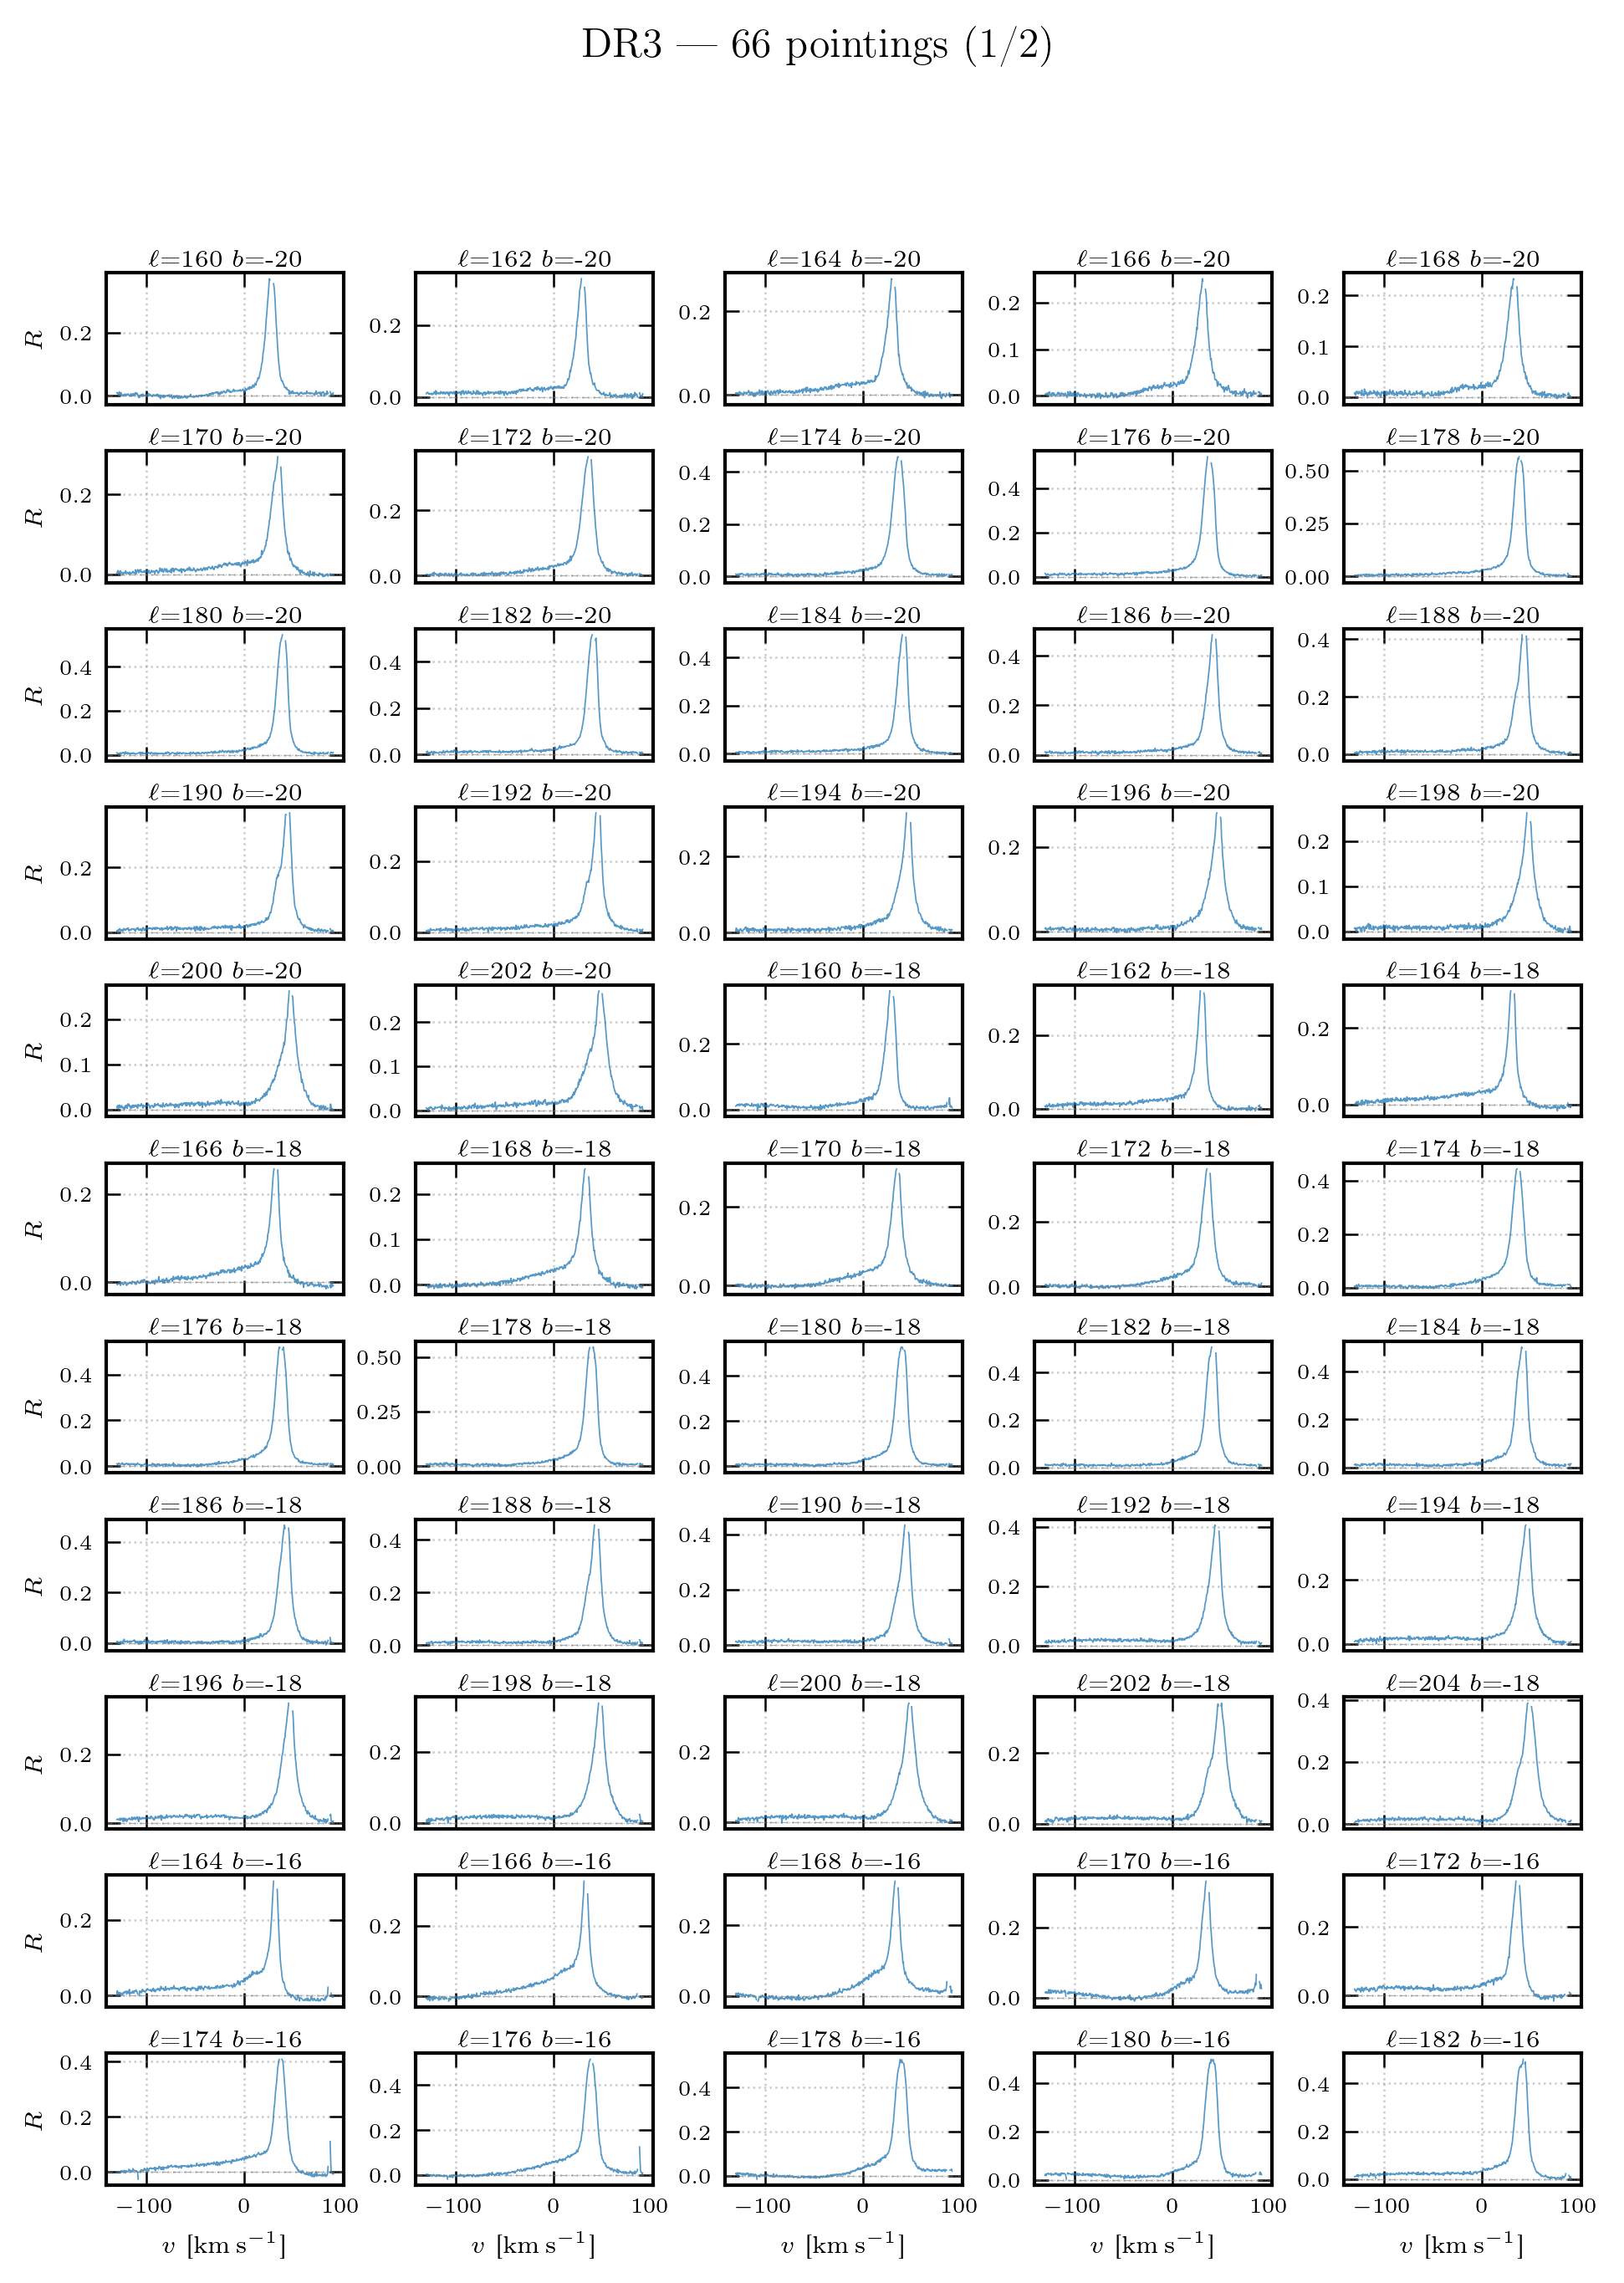

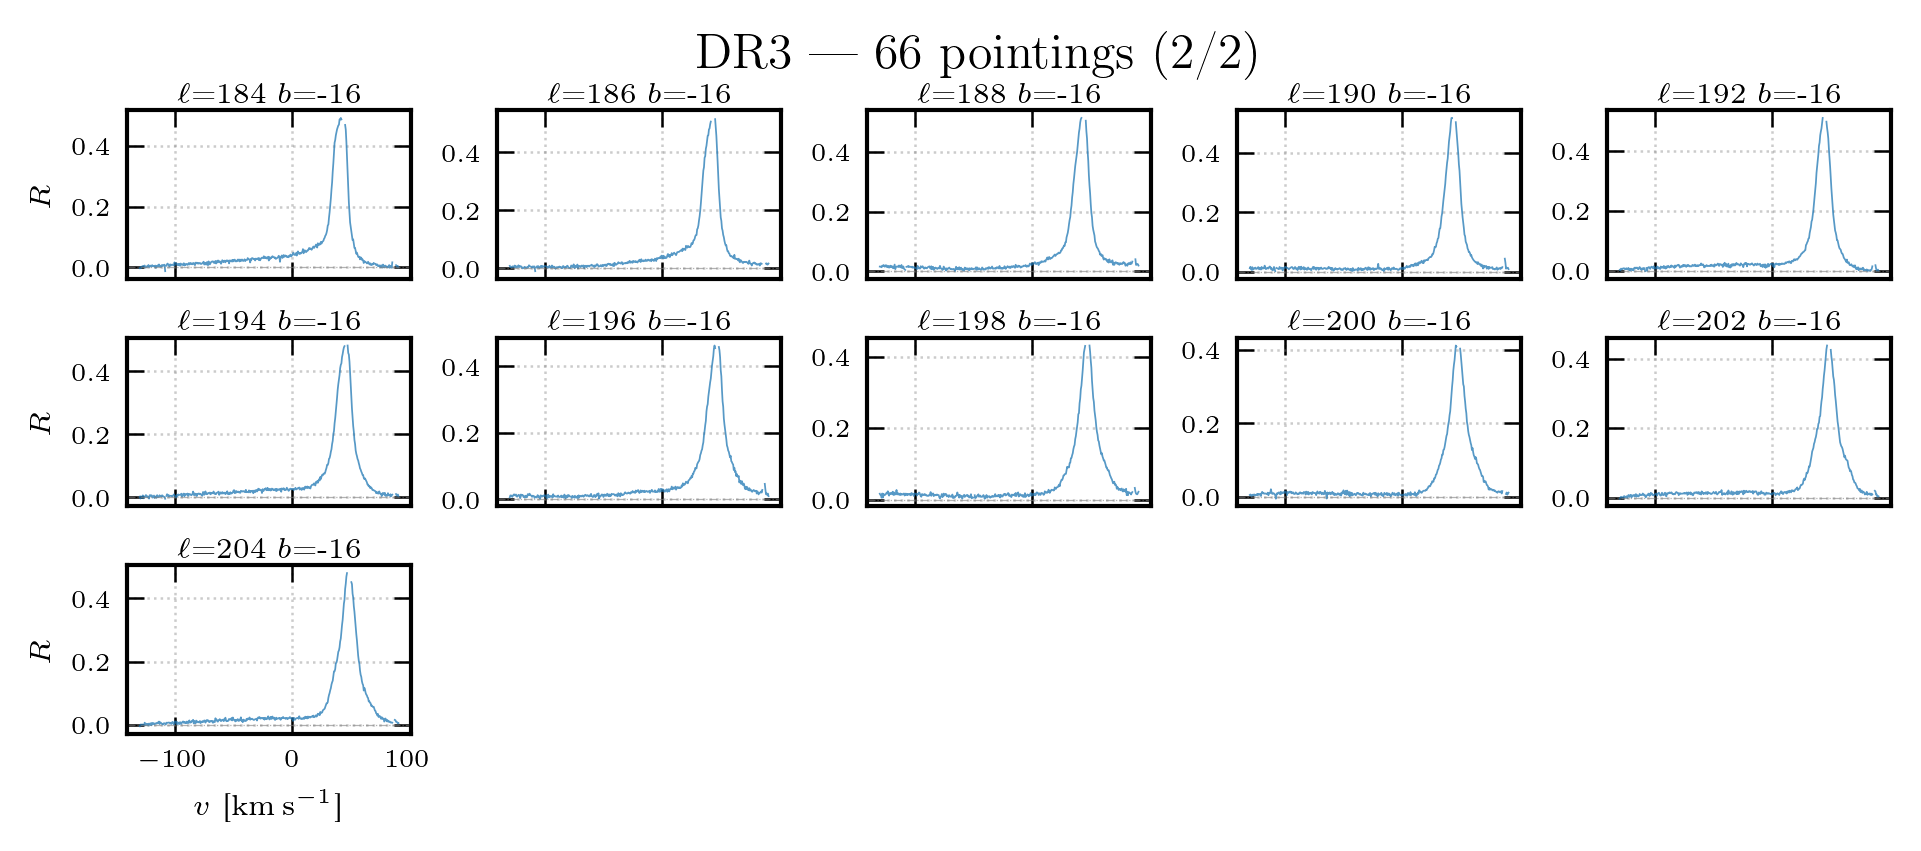

In [8]:
for dr in DATA_RELEASES:
    dr_spectra = {(l, b): cell_results[(d, l, b)]['R_overlap']
                  for (d, l, b) in cell_results if d == dr}
    if not dr_spectra:
        continue
    result = plot_spectra_grid(v_overlap, dr_spectra, title=f'{dr} — {len(dr_spectra)} pointings')
    figs = result if isinstance(result, list) else [result]
    for f in figs:
        plt.show()

## 5a. Telescope pointing trace per DR

Scan pattern in galactic coordinates and alt/az Mollweide showing the
actual telescope path through each dump, colored by time order.

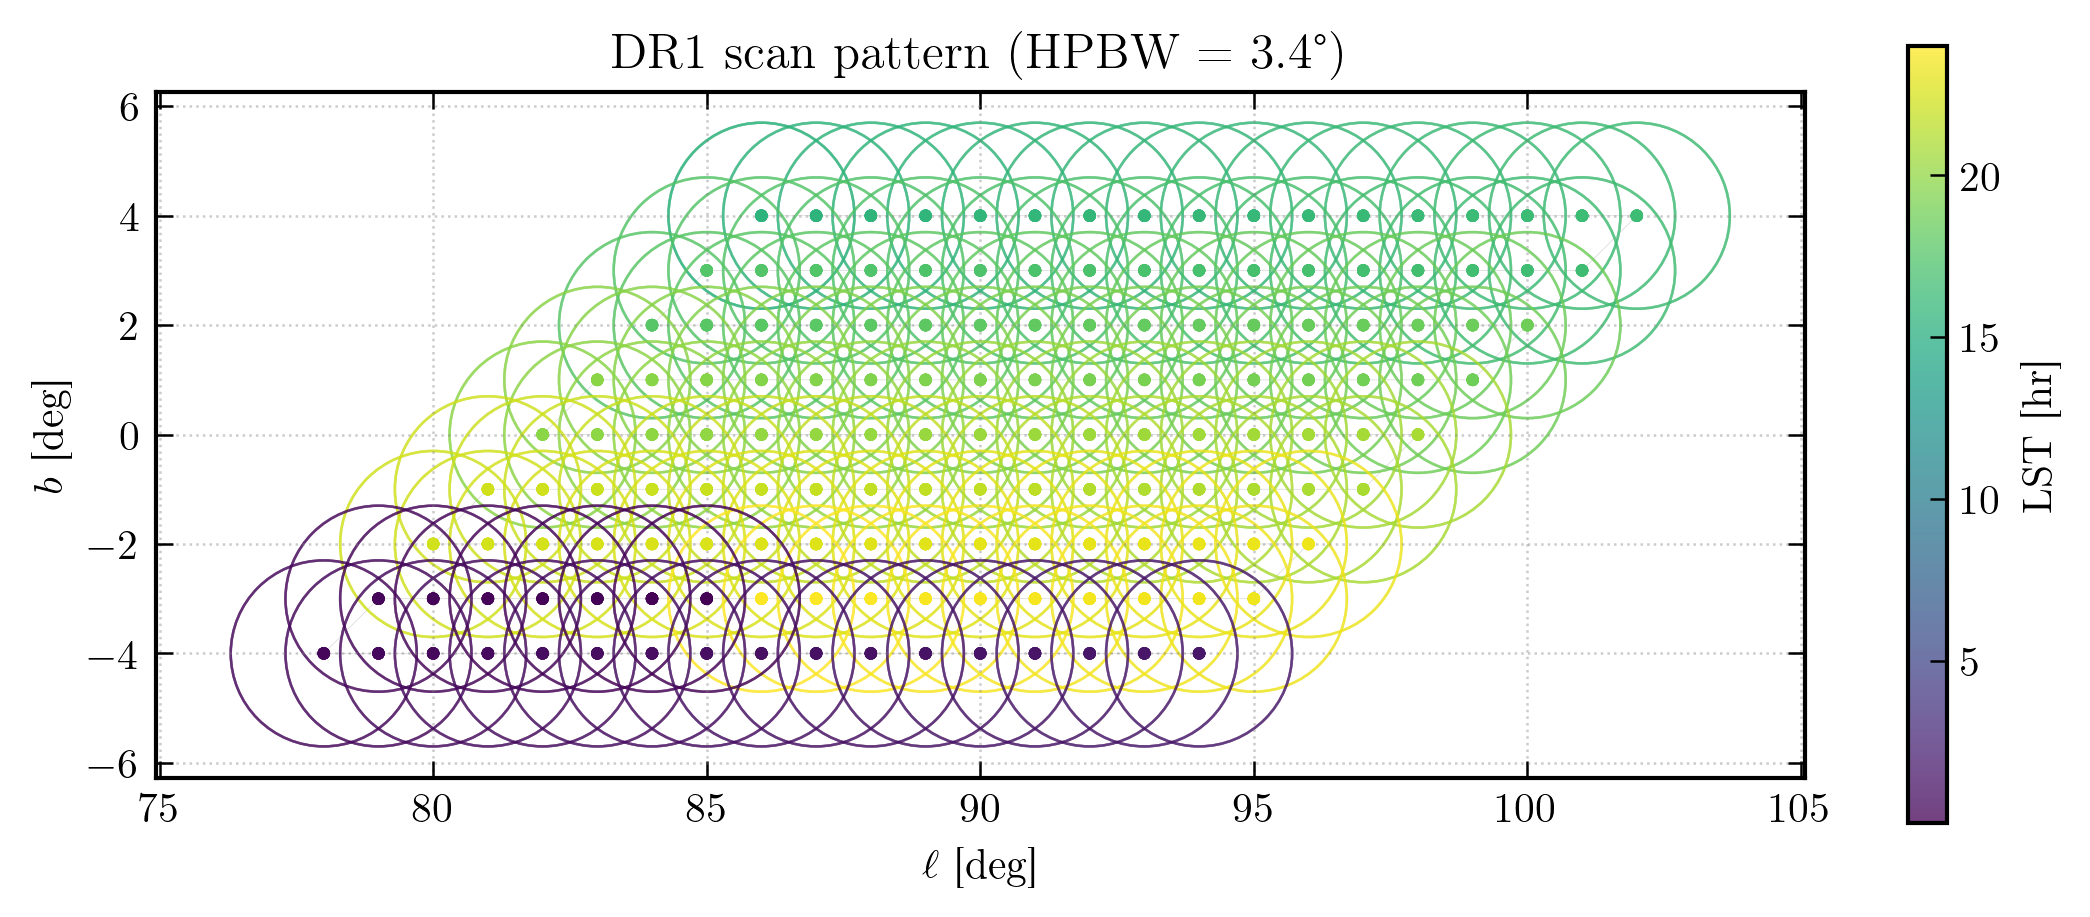

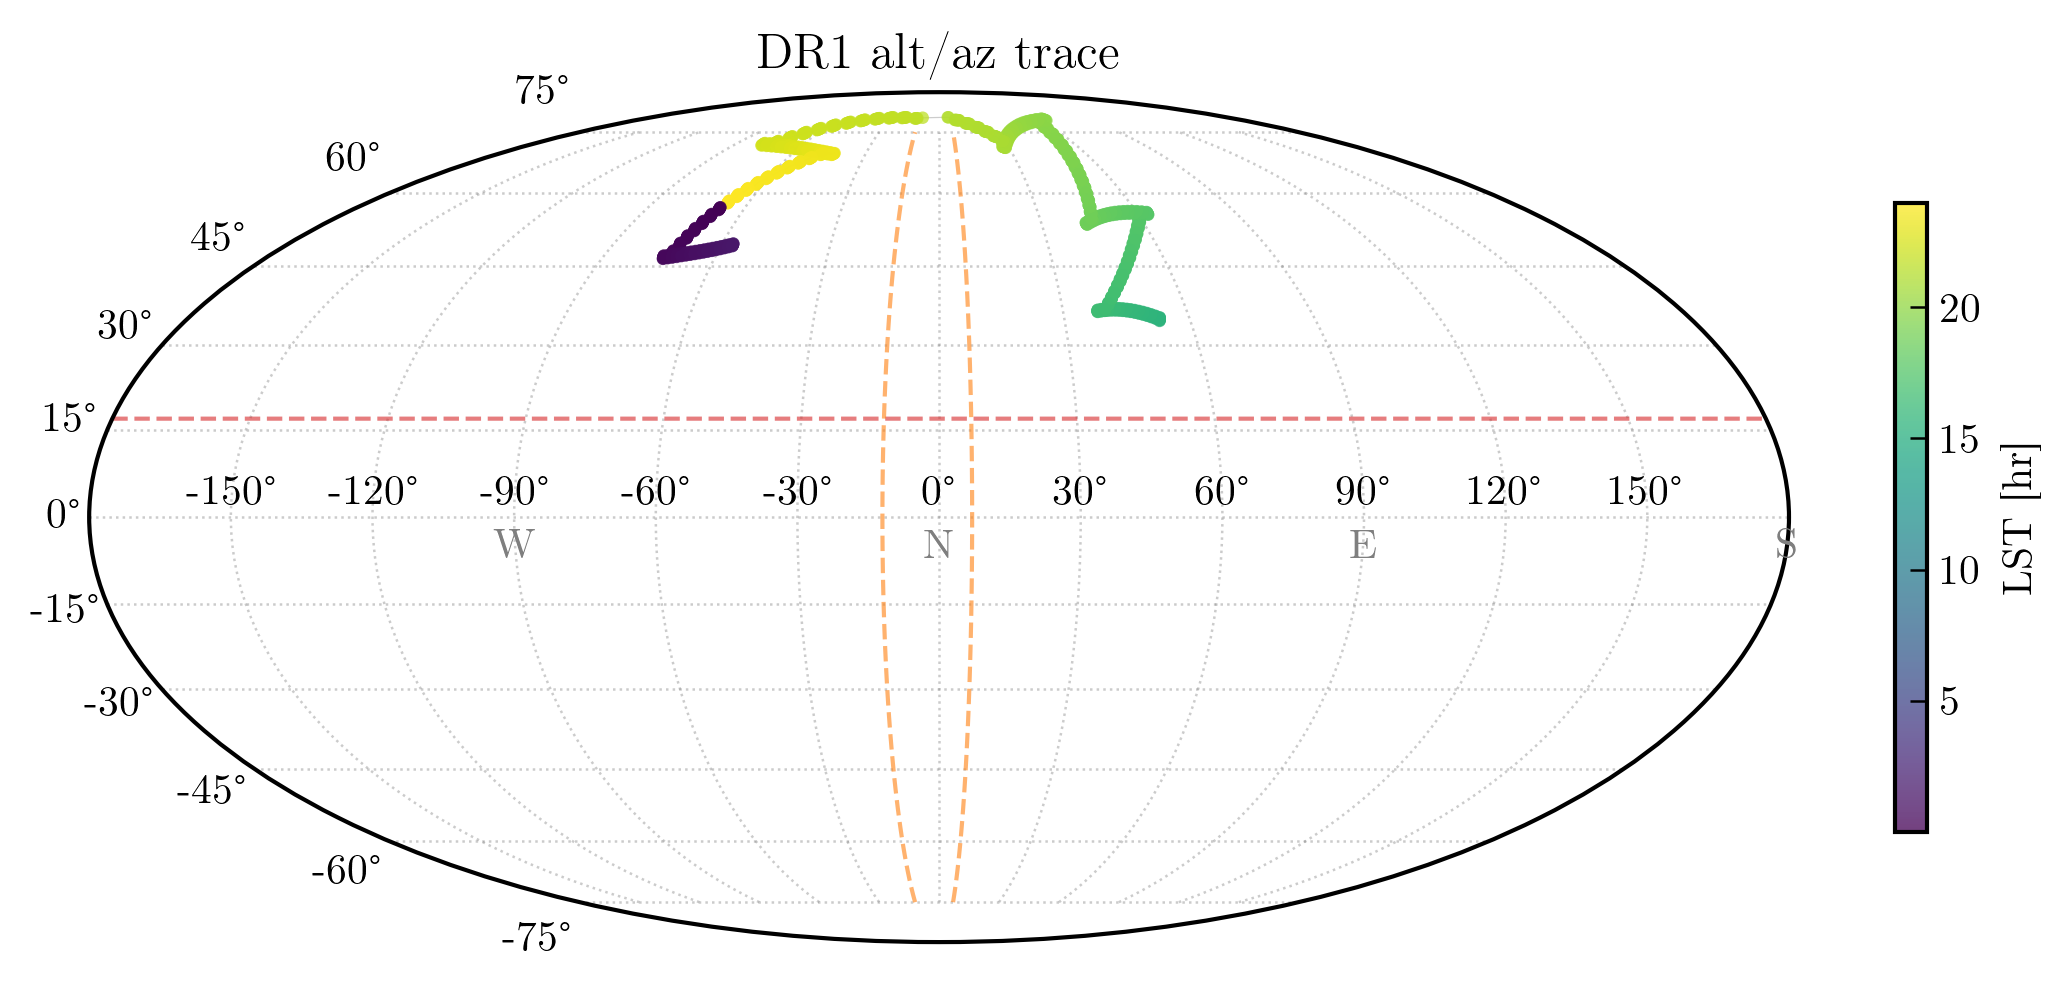

DR1: 1225 dumps, LST 0.0–24.0 hr, alt [34–79], az [5–350]


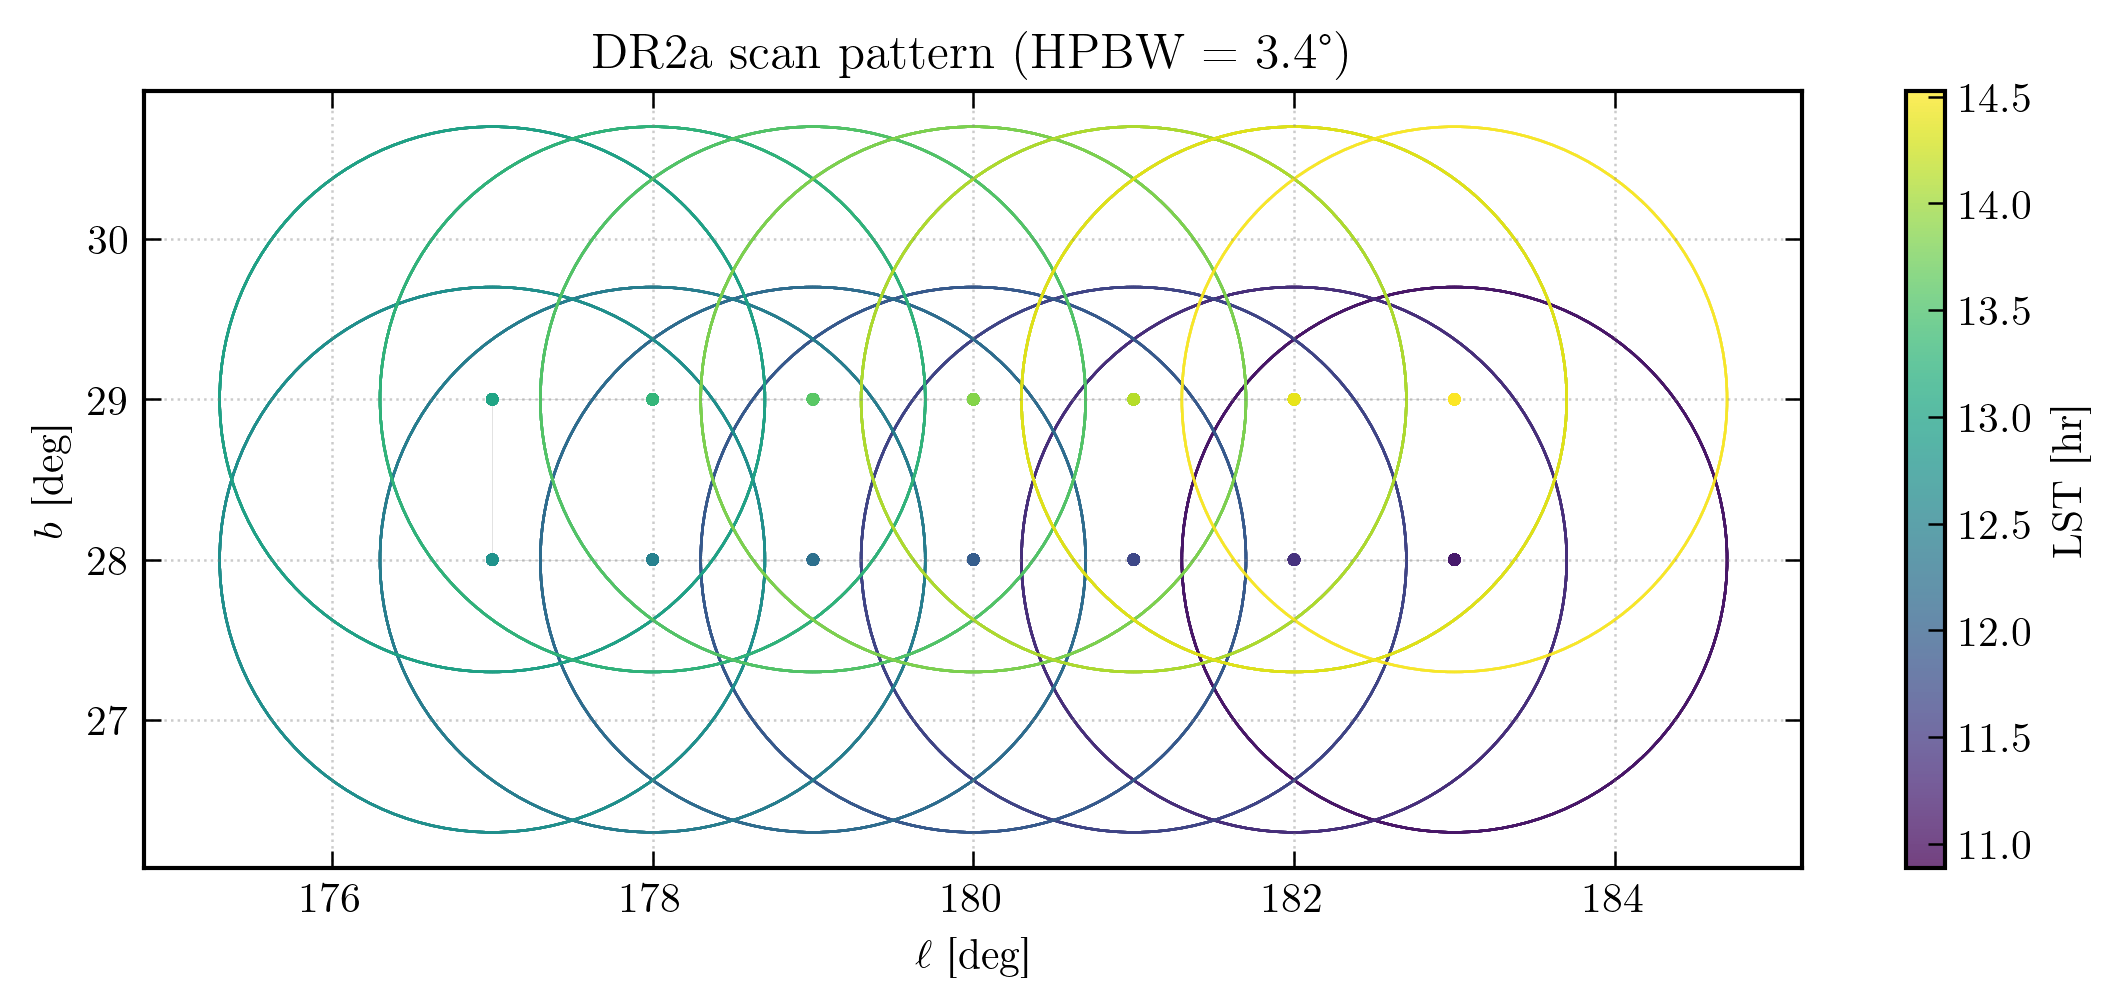

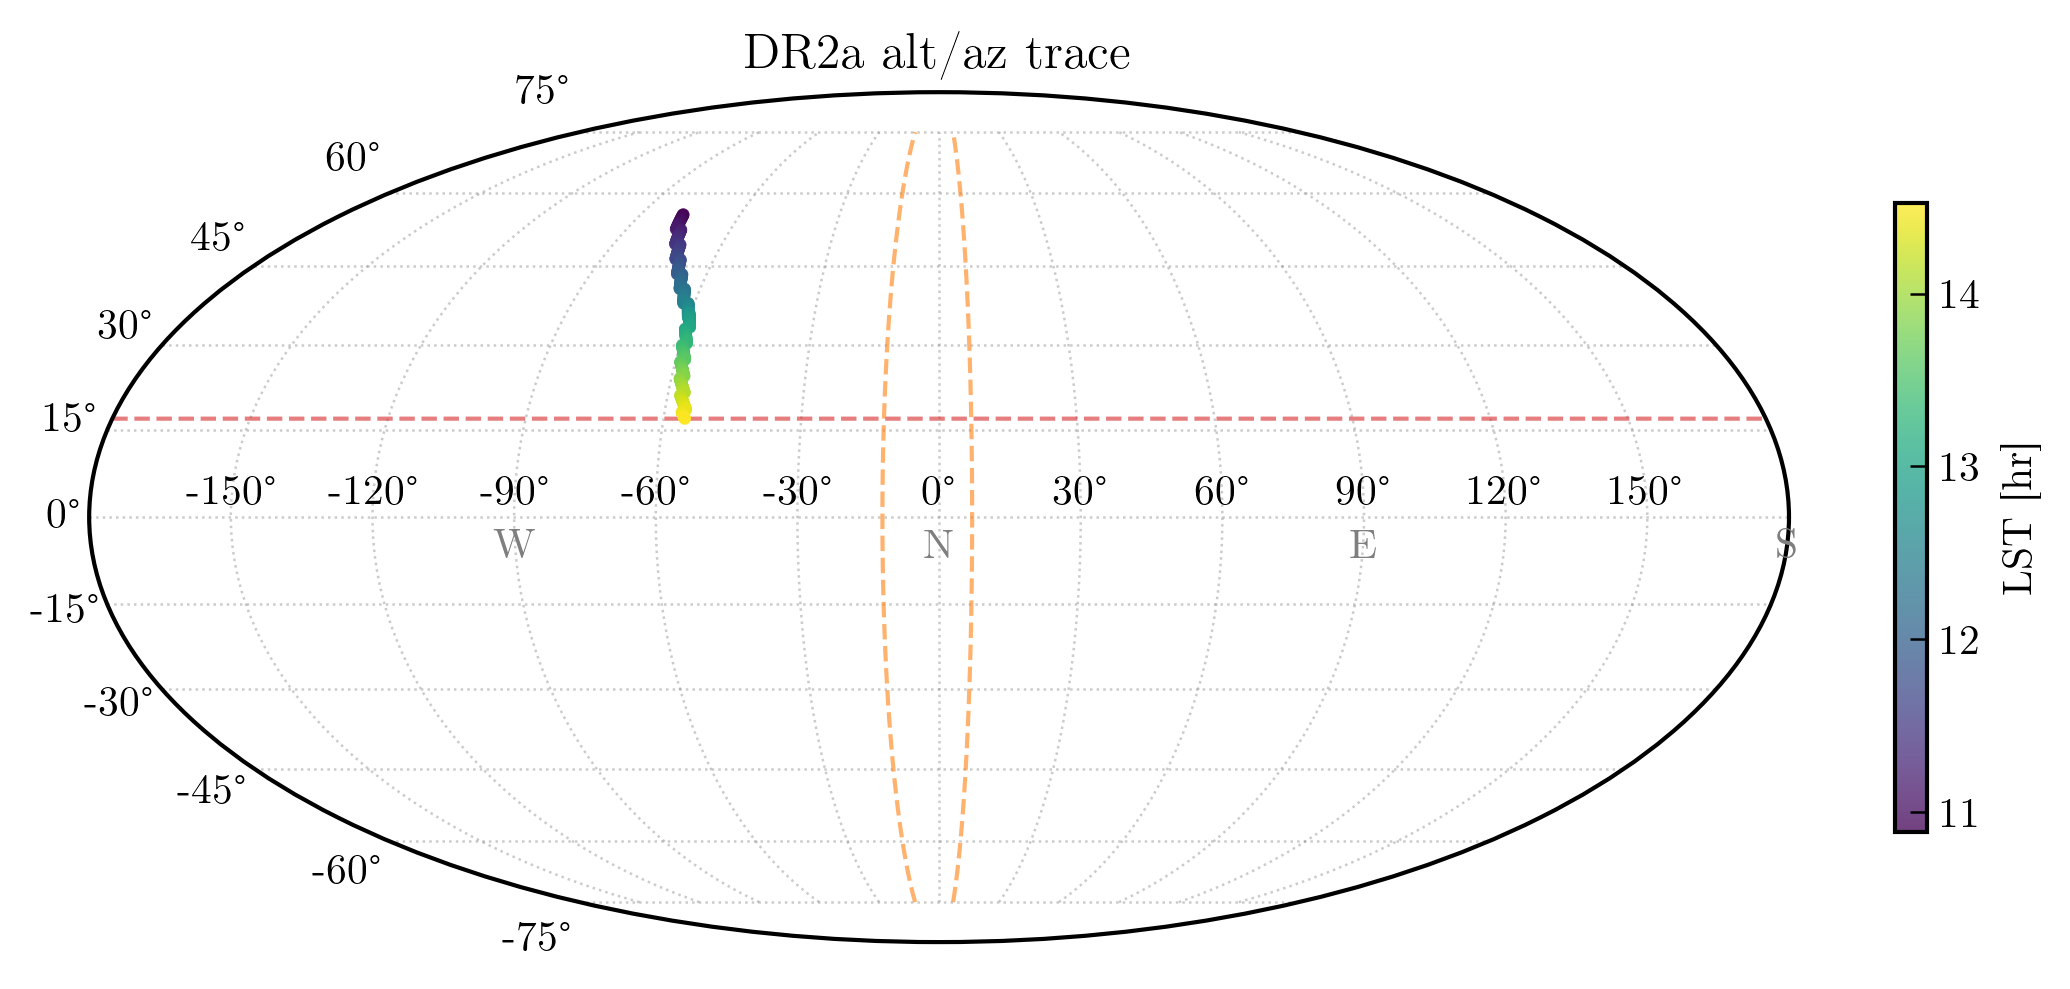

DR2a: 432 dumps, LST 10.9–14.5 hr, alt [17–55], az [283–305]


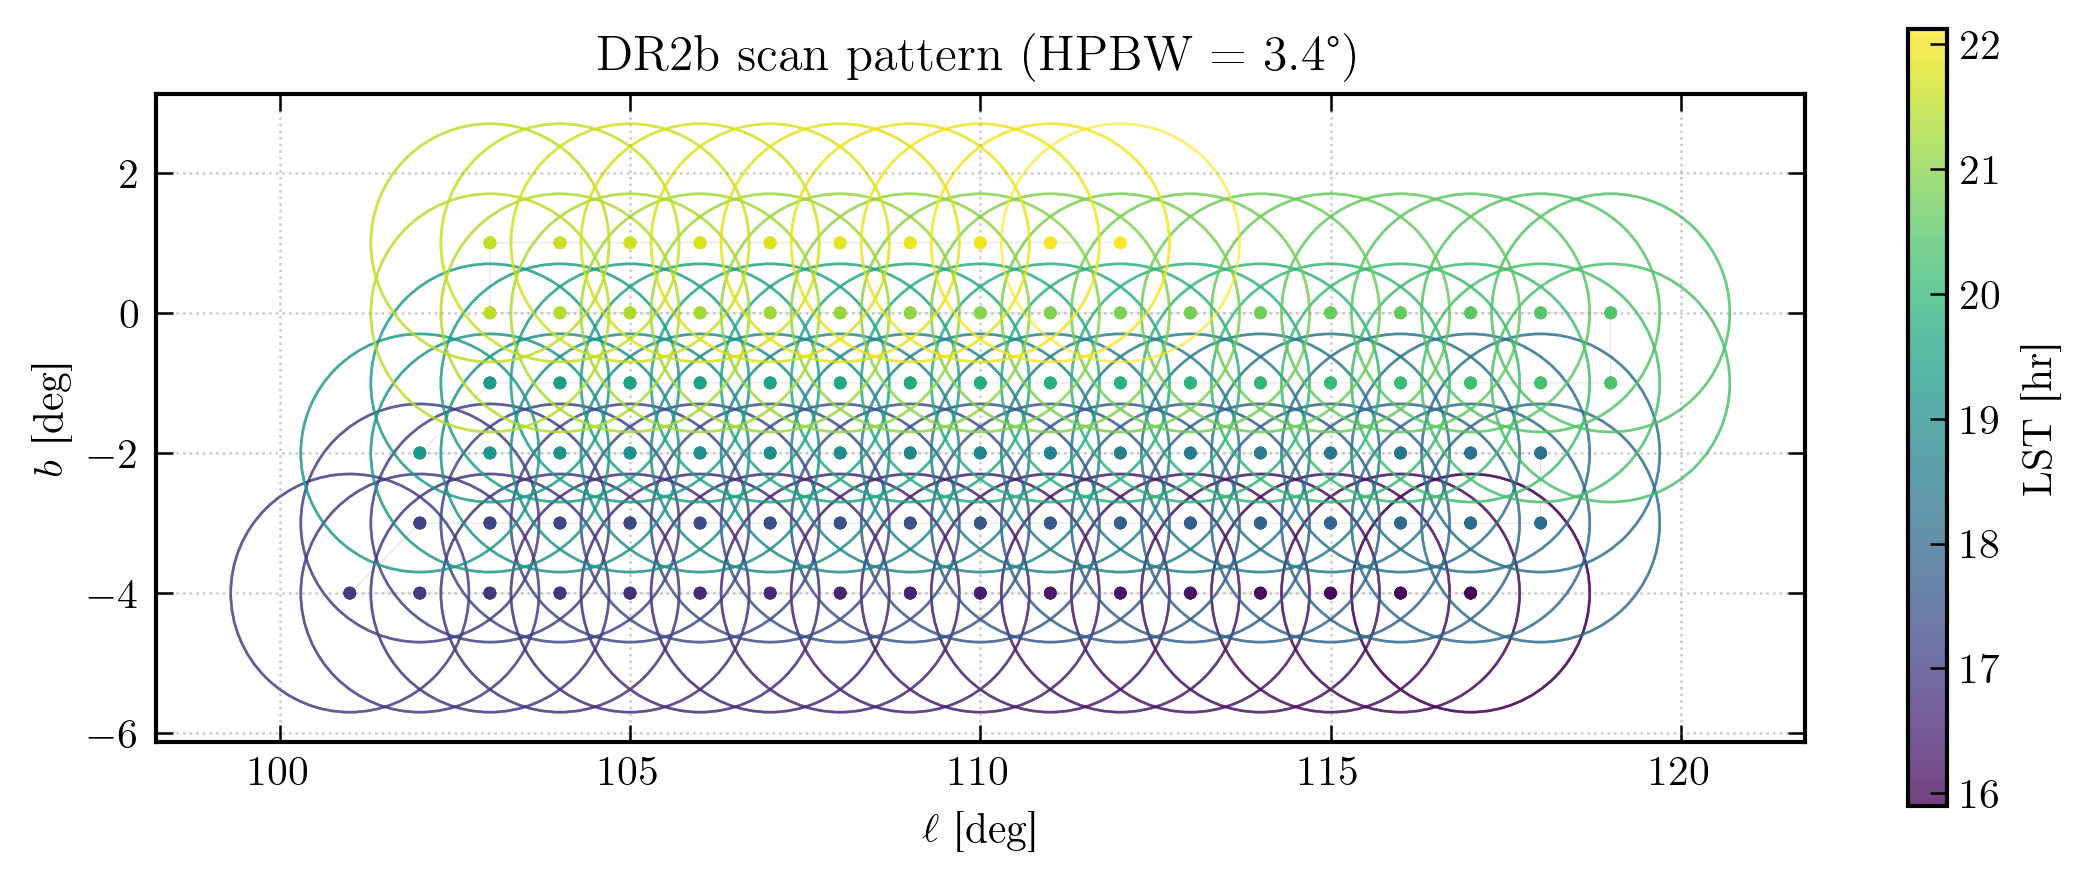

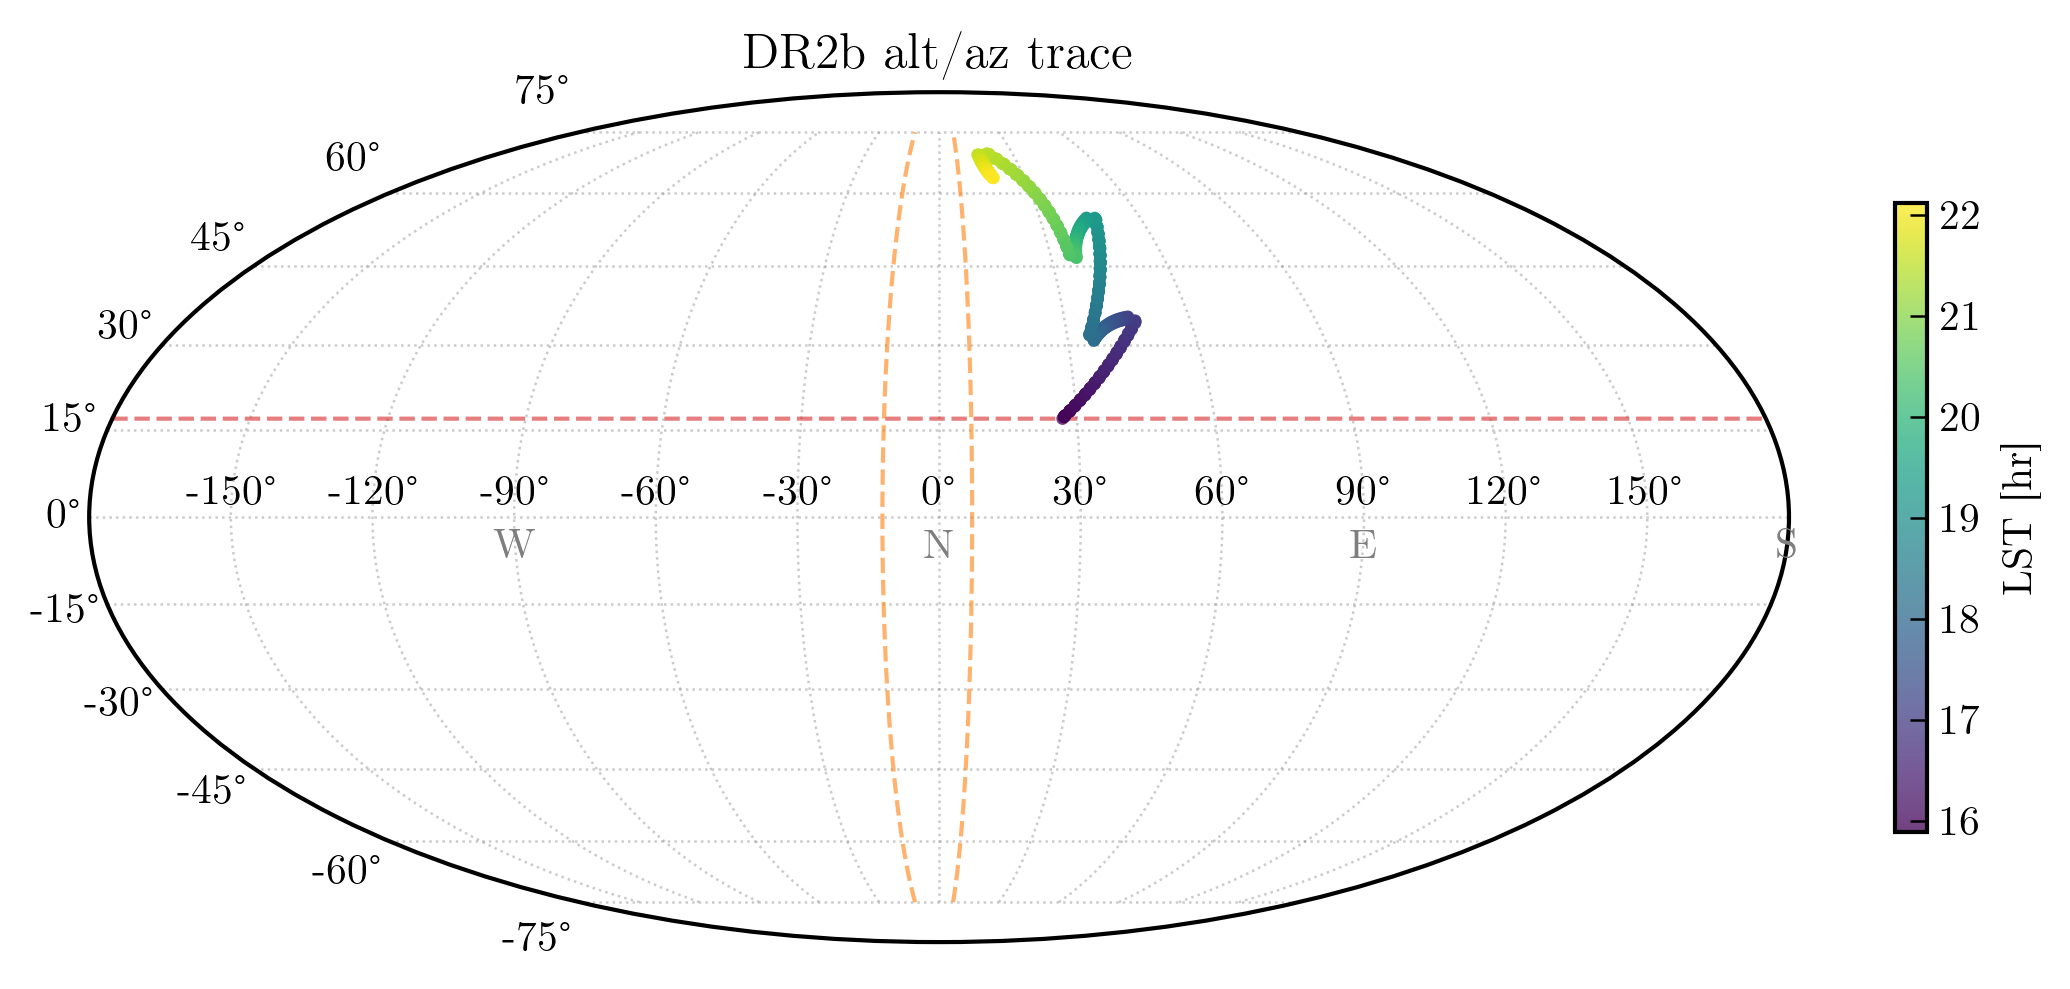

DR2b: 758 dumps, LST 15.9–22.1 hr, alt [17–69], az [16–47]


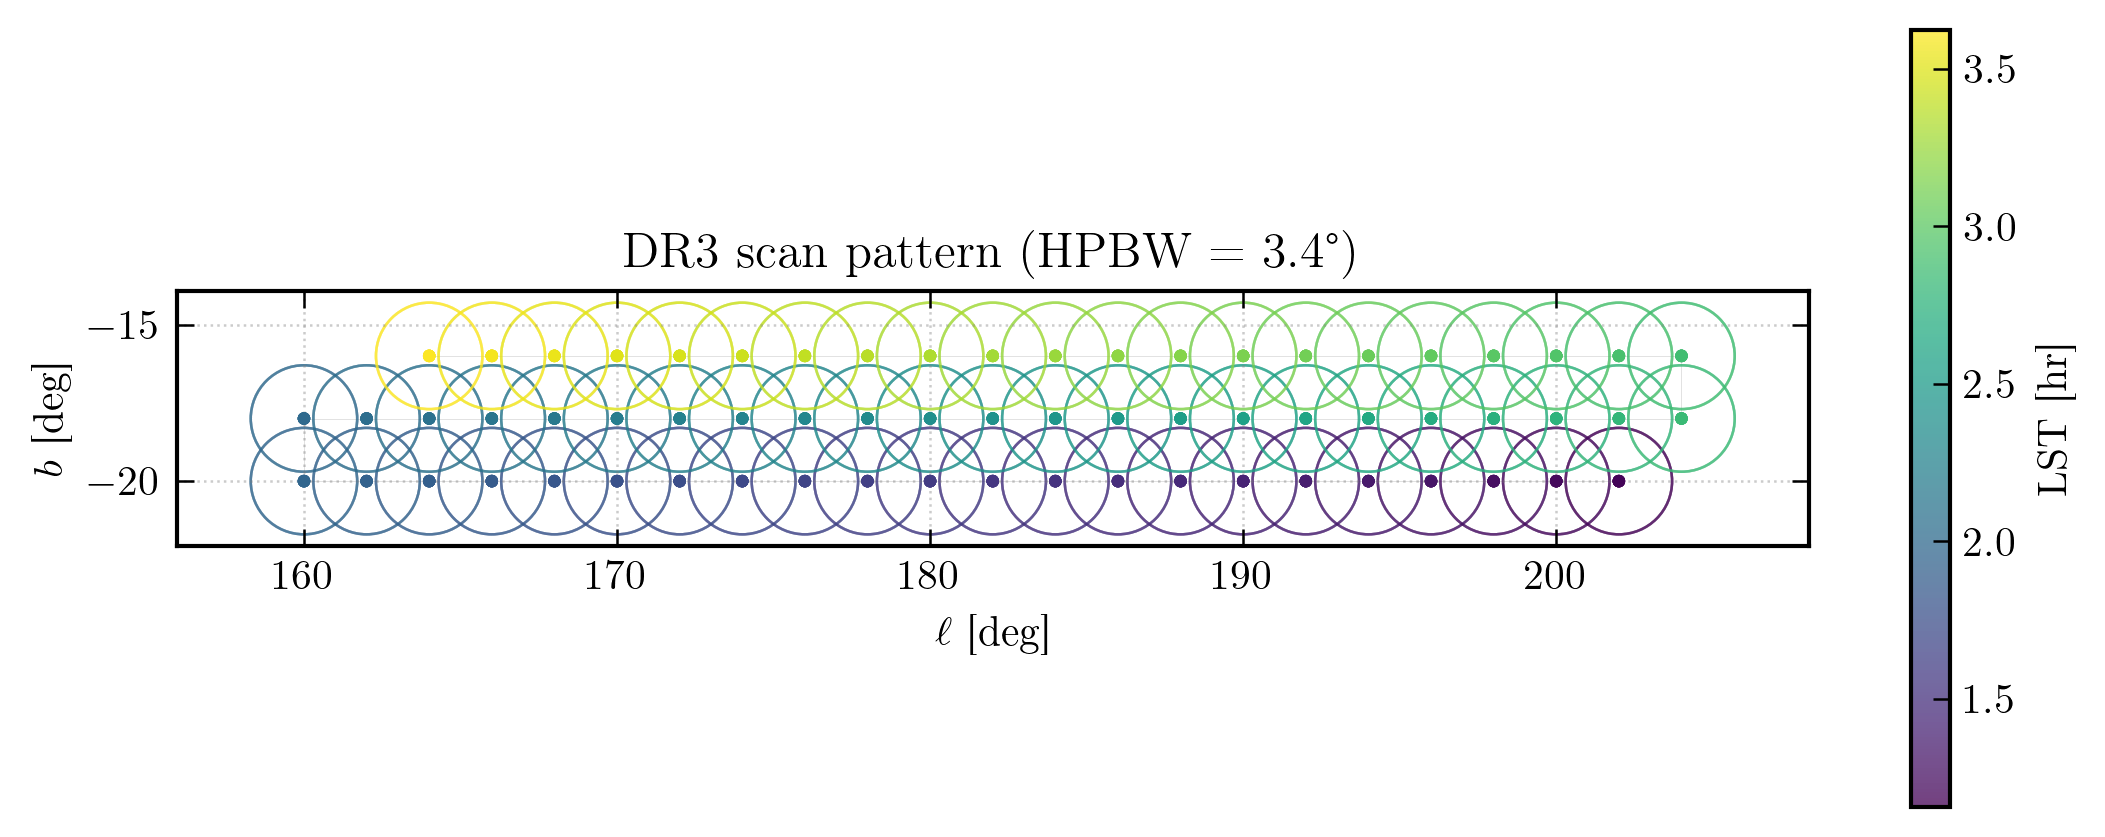

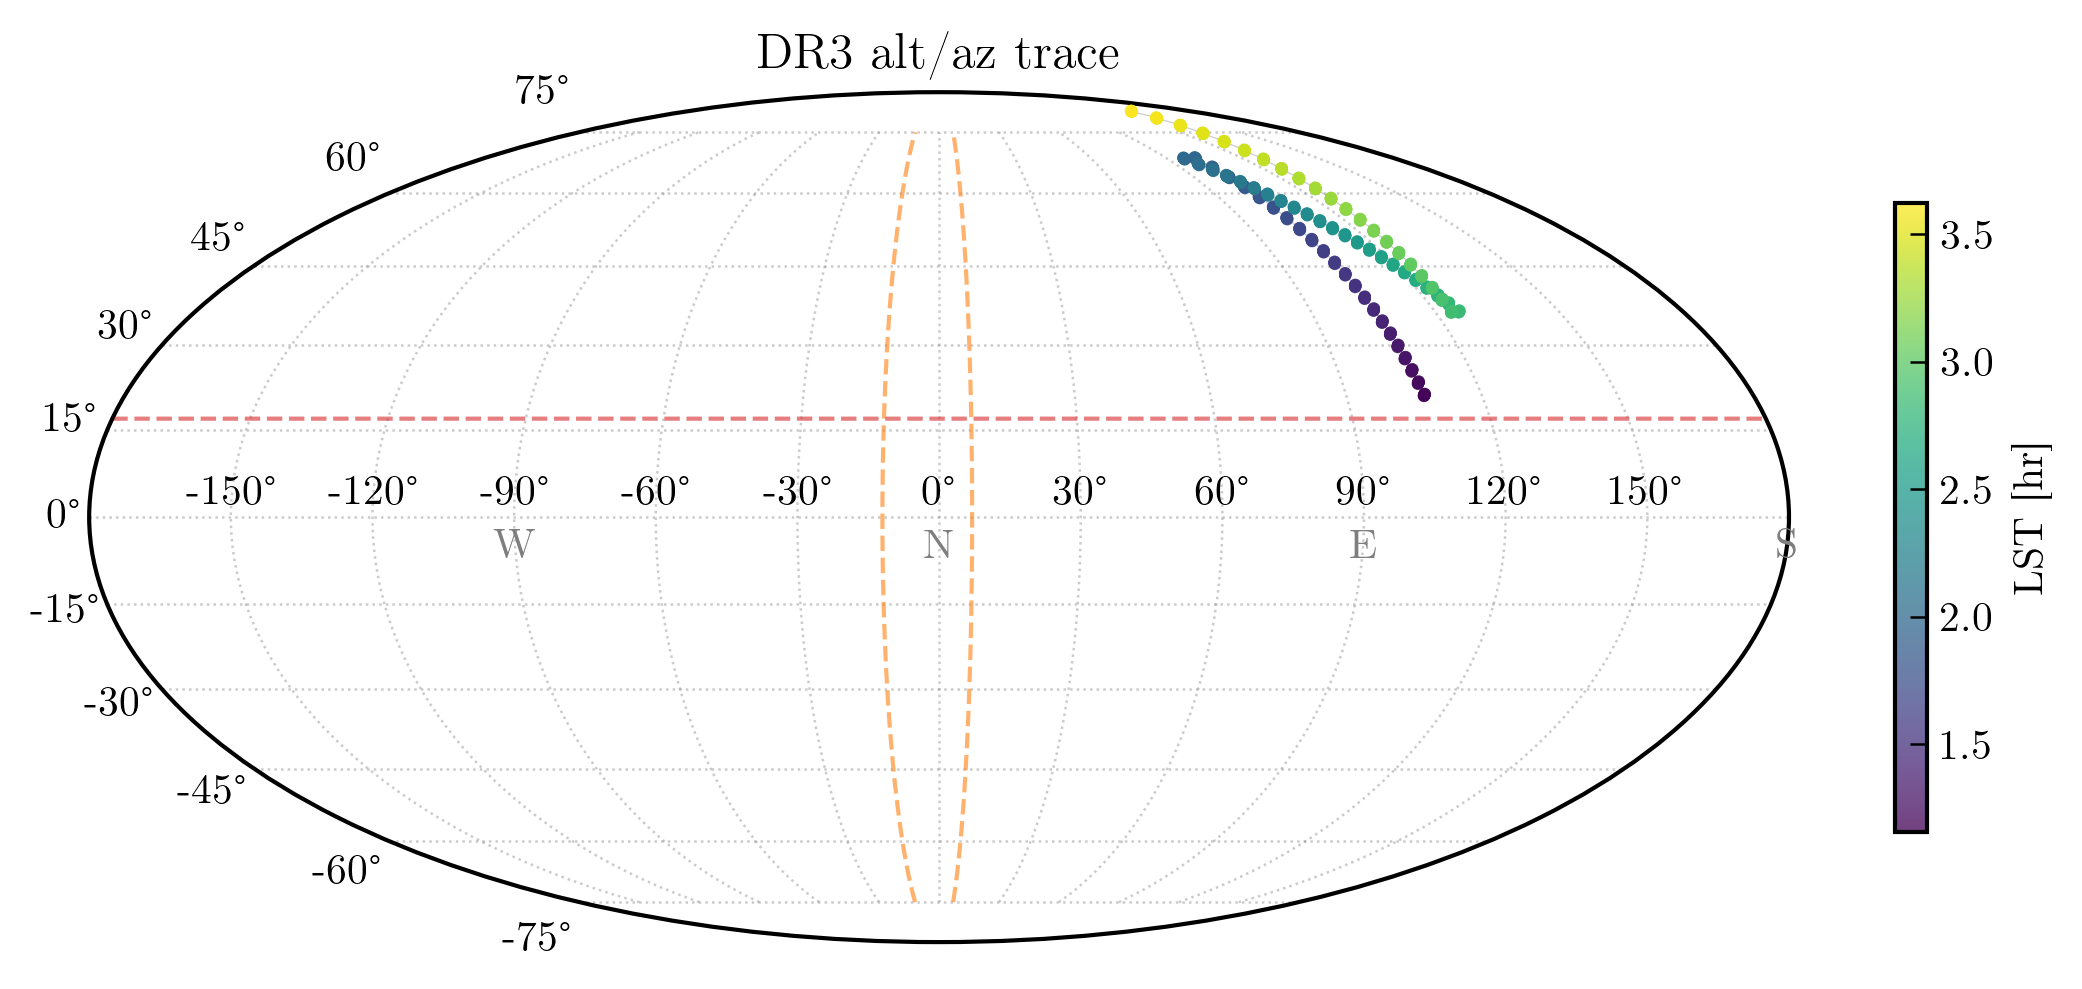

DR3: 528 dumps, LST 1.2–3.6 hr, alt [21–82], az [97–139]


In [9]:
from matplotlib.patches import Circle
from astropy.time import Time as AstroTime
import matplotlib.dates as mdates

HPBW_DEG = 3.4
LEO_LON = -122.1067

for dr in DATA_RELEASES:
    dr_recs = sorted([r for r in records if r['dr'] == dr and r['row'] >= 0],
                     key=lambda r: r['time'])
    if len(dr_recs) < 2:
        continue

    gl_dr = np.array([r['gl'] for r in dr_recs], dtype=float)
    gb_dr = np.array([r['gb'] for r in dr_recs], dtype=float)
    alt_dr = np.array([r['alt'] for r in dr_recs])
    az_dr = np.array([r['az'] for r in dr_recs])
    t_dr = np.array([r['time'] for r in dr_recs])

    # Compute actual LST for each dump
    lst_hrs = np.array([
        AstroTime(t, format='unix').sidereal_time(
            'apparent', longitude=LEO_LON * u_ast.deg
        ).hour for t in t_dr
    ])

    # --- Galactic scan pattern with beam circles colored by LST ---
    fig, ax = plt.subplots(figsize=(plotting.TEXTWIDTH_IN, 4))
    cmap = plt.cm.viridis

    vmin, vmax = lst_hrs.min(), lst_hrs.max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for i in range(len(gl_dr)):
        c = cmap(norm(lst_hrs[i]))
        beam = Circle((gl_dr[i], gb_dr[i]), HPBW_DEG / 2,
                       fill=False, edgecolor=c,
                       alpha=plotting.ALPHA_EXTRA_LIGHT, lw=plotting.LW_FINE)
        ax.add_patch(beam)

    sc = ax.scatter(gl_dr, gb_dr, c=lst_hrs, cmap='viridis',
                    s=plotting.SS_FINE, edgecolors='none',
                    alpha=plotting.ALPHA_STANDARD, zorder=5,
                    vmin=vmin, vmax=vmax)
    ax.plot(gl_dr, gb_dr, lw=plotting.LW_FINE * 0.3, color='k',
            alpha=0.15, zorder=0)
    ax.set_xlabel(r'$\ell$ [deg]', fontsize=plotting.LABEL_SIZE)
    ax.set_ylabel(r'$b$ [deg]', fontsize=plotting.LABEL_SIZE)
    ax.set_title(f'{dr} scan pattern (HPBW = {HPBW_DEG}°)', fontsize=plotting.EMPHASIS_SIZE)
    ax.set_aspect('equal')
    ax.grid(True, **plotting.GRID_STYLE)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
    cbar.set_label('LST [hr]')
    fig.tight_layout()
    plt.show()

    # --- Alt/Az Mollweide trace colored by LST ---
    az_moll = np.where(az_dr > 180, az_dr - 360, az_dr)

    fig = plt.figure(figsize=(plotting.TEXTWIDTH_IN, plotting.TEXTWIDTH_IN / 16 * 8))
    ax = fig.add_subplot(111, projection='mollweide')
    ax.grid(True, **{k: v for k, v in plotting.GRID_STYLE.items() if k != 'color'},
            color=plotting.NEUTRAL_COLOR)

    az_line = np.linspace(-np.pi, np.pi, 500)
    ax.plot(az_line, np.full_like(az_line, np.deg2rad(17)),
            lw=plotting.LW_LIGHT, ls='--', color='C3', alpha=plotting.ALPHA_LIGHT)
    for az_lim in [7, 348]:
        az_l = az_lim if az_lim <= 180 else az_lim - 360
        ax.axvline(np.deg2rad(az_l), lw=plotting.LW_LIGHT, ls='--',
                   color='C1', alpha=plotting.ALPHA_LIGHT)

    ax.plot(np.deg2rad(az_moll), np.deg2rad(alt_dr),
            lw=plotting.LW_FINE * 0.5, color='k', alpha=0.2, zorder=0)
    sc = ax.scatter(np.deg2rad(az_moll), np.deg2rad(alt_dr),
                    c=lst_hrs, cmap='viridis', s=plotting.SS_FINE,
                    edgecolors='none', alpha=plotting.ALPHA_STANDARD, zorder=5,
                    vmin=vmin, vmax=vmax)

    for azd, name in [(0, 'N'), (90, 'E'), (180, 'S'), (-90, 'W')]:
        ax.annotate(name, (np.deg2rad(azd), np.deg2rad(-2)),
                    fontsize=plotting.TICK_SIZE, ha='center', va='top',
                    fontweight='bold', color=plotting.NEUTRAL_COLOR)

    ax.set_title(f'{dr} alt/az trace', fontsize=plotting.EMPHASIS_SIZE)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
    cbar.set_label('LST [hr]')
    fig.tight_layout()
    plt.show()

    print(f'{dr}: {len(dr_recs)} dumps, LST {lst_hrs.min():.1f}–{lst_hrs.max():.1f} hr, '
          f'alt [{alt_dr.min():.0f}–{alt_dr.max():.0f}], az [{az_dr.min():.0f}–{az_dr.max():.0f}]')

## 6. Summary

In [10]:
all_times = [r['time'] for r in records]
t0 = dt.datetime.fromtimestamp(min(all_times), tz=dt.UTC)
t1 = dt.datetime.fromtimestamp(max(all_times), tz=dt.UTC)
wall = max(all_times) - min(all_times)

print(f'Scan grid:  {len(rows)} x {len(cols)} = {len(cell_results)} cells with data')
print(f'LO freqs:   {lo_unique} MHz')
print(f'Start:      {t0:%Y-%m-%d %H:%M:%S UTC}')
print(f'End:        {t1:%Y-%m-%d %H:%M:%S UTC}')
print(f'Duration:   {wall/60:.1f} min')
print(f'Dumps:      {N} ({n_cal} cal + {n_sci} science)')
print(f'Channels:   {NFFT} (dnu={df_khz:.2f} kHz)')

Scan grid:  9 x 23 = 328 cells with data
LO freqs:   [1420.0, 1421.0] MHz
Start:      2026-04-16 09:57:55 UTC
End:        2026-04-17 22:01:39 UTC
Duration:   2163.7 min
Dumps:      2943 (16 cal + 2936 science)
Channels:   1024 (dnu=2.50 kHz)


## 7. Update survey manifest

Write the manifest file with per-pointing completeness status.
Push this file to the observation Pi so `observe_otf.py` can skip complete cells.

In [11]:
from manifest import write_manifest, pairs_target

# Build pointing dump counts from records (already have gl, gb assigned)
manifest_pointings = {}
for r in records:
    if r.get('gl') is None or r['noise_on']:
        continue
    key = (r['gl'], r['gb'])
    if key not in manifest_pointings:
        manifest_pointings[key] = {'n_1420': 0, 'n_1421': 0}
    if r['lo_mhz'] == 1420.0:
        manifest_pointings[key]['n_1420'] += 1
    elif r['lo_mhz'] == 1421.0:
        manifest_pointings[key]['n_1421'] += 1

MANIFEST_PATH = Path('../survey_manifest.json')
write_manifest(manifest_pointings, MANIFEST_PATH)

# Show incomplete cells
from manifest import read_manifest
pointings = read_manifest(MANIFEST_PATH)
incomplete = {lb: info for lb, info in pointings.items() if not info['complete']}
if incomplete:
    print(f'\nIncomplete cells ({len(incomplete)}):')
    print(f'  {"l":>4} {"b":>4} {"pairs":>5} {"target":>6} {"need":>5}')
    for (l, b), info in sorted(incomplete.items()):
        need = info['target'] - info['n_pairs']
        print(f'  {l:>4} {b:>+4} {info["n_pairs"]:>5} {info["target"]:>6} {need:>5}')
else:
    print('\nAll cells complete!')

Manifest written: ../survey_manifest.json
  328 pointings: 325 complete, 3 incomplete

Incomplete cells (3):
     l    b pairs target  need
    86   +4     2      4     2
   112   +1     2      4     2
   117   -4     2      4     2
